In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as ss
from scipy import signal
from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

import mc3

from tqdm import tqdm

import tools as t

## Extract data

In [2]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')
data_rv.keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

data_spectra: matrix with 3686 spectra of 122 elements each \
data_rv: dictionary

In [3]:
c = 3e8  # m/s
# extract data
wl = data_rv['lambd']
rv_ccf = data_rv['rv_correl']
template = data_rv['flux_moy']
times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days
times

array([0.000e+00, 1.000e-01, 2.000e-01, ..., 3.683e+02, 3.684e+02,
       3.685e+02], shape=(3686,))

In [4]:
max(wl)

np.float64(6173.599098)

In [5]:
len(data_spectra)

3686

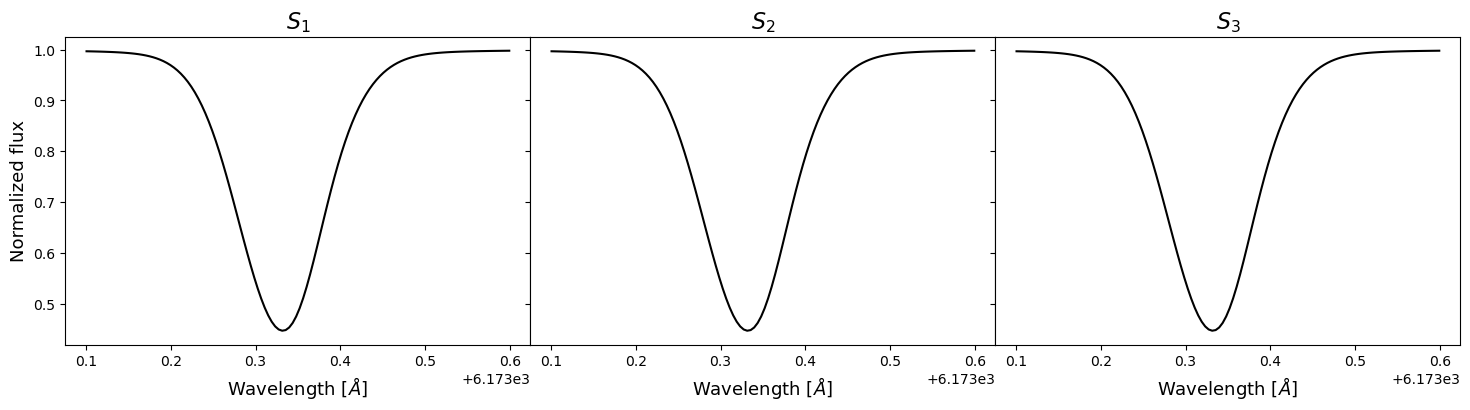

In [6]:
# plot some spectra
n_spectra = 3
fig, axs = plt.subplots(1, n_spectra, figsize=(18, 4), sharey=True)
axs[0].set_ylabel('Normalized flux', size=13)
for i in range(n_spectra):
    axs[i].plot(wl, data_spectra[i], color='k')
    axs[i].set_title(f'$S_{i+1}$', size=16)
    axs[i].set_xlabel(r'Wavelength [$\AA$]', size=13)
plt.subplots_adjust(wspace=0)
plt.show()

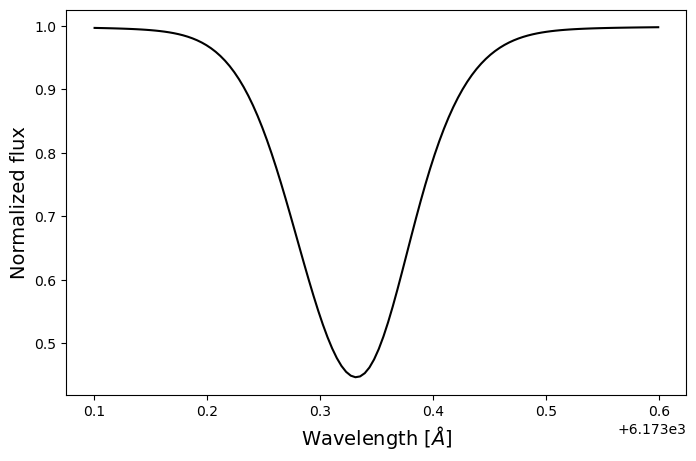

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(wl, data_spectra[0], color='k')
#ax.set_title(f'Simulated Fe I 6173 line', size=16)
ax.set_xlabel(r'Wavelength [$\AA$]', size=14)
ax.set_ylabel('Normalized flux', size=14)
plt.show()

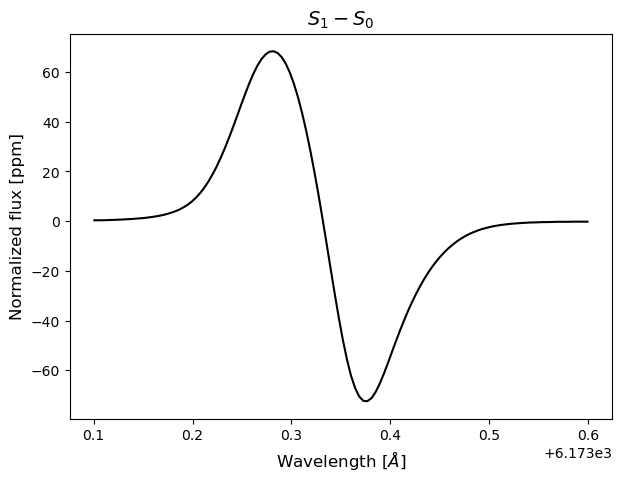

In [8]:
# show that variations between one spectrum and another are small
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(wl, (data_spectra[1] - data_spectra[0]) * 10**6, color='k')
ax.set_title(r'$S_1 - S_0$', size=14)
ax.set_xlabel(r'Wavelength [$\AA$]', size=12)
ax.set_ylabel('Normalized flux [ppm]', size=12)
plt.show()

## Calculate RV by template matching

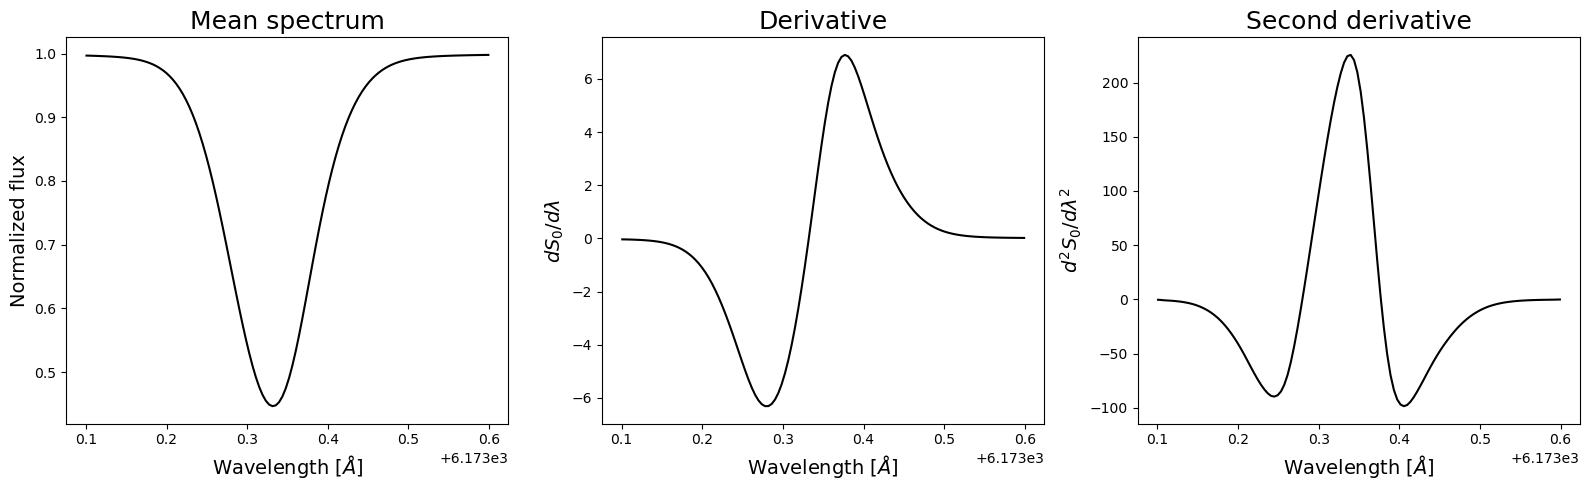

In [9]:
# template matching: calculate the mean spectrum
mean_spec = np.mean(data_spectra, axis=0)
d_S0 = np.gradient(mean_spec, wl)  # derivative of the mean spectrum
d2_S0 = np.gradient(d_S0, wl)  # second derivative of the mean spectrum

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs[0].plot(wl, mean_spec, color='k')
axs[0].set_title('Mean spectrum', size=18)
axs[0].set_xlabel(r'Wavelength [$\AA$]', size=14)
axs[0].set_ylabel('Normalized flux', size=14)

axs[1].plot(wl, d_S0, color='k')
axs[1].set_title('Derivative', size=18)
axs[1].set_xlabel(r'Wavelength [$\AA$]', size=14)
axs[1].set_ylabel(r'$dS_0 / d\lambda$', size=14)

axs[2].plot(wl, d2_S0, color='k')
axs[2].set_title('Second derivative', size=18)
axs[2].set_xlabel(r'Wavelength [$\AA$]', size=14)
axs[2].set_ylabel(r'$d^2S_0 / d\lambda^2$', size=14)

fig.tight_layout()
plt.show()

In [10]:
peaks, properties = signal.find_peaks(d_S0)
print(wl[43], wl[67])

6173.277862 6173.376704


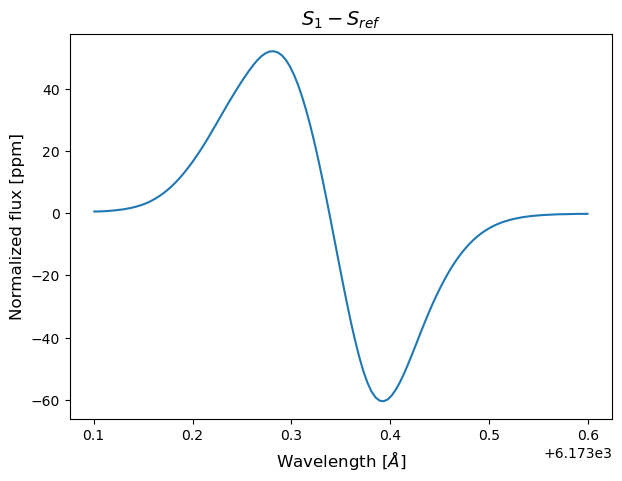

In [11]:
# first spectrum - reference spectrum
# small differences between one spectrum and other
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wl, (data_spectra[1] - mean_spec) * 10**6)
ax.set_title(r'$S_1 - S_{ref}$', size=14)
ax.set_xlabel(r'Wavelength [$\AA$]', size=12)
ax.set_ylabel('Normalized flux [ppm]', size=12)
plt.show()

In [12]:
# calculate radial velocity by template matching
C_0 = 1000
rv_tm = []
for k in range(len(data_spectra)):  # for each spectrum
    rv_tm.append(t.calculate_rv(wl, mean_spec, data_spectra[k], C_0))
rv_tm = np.array(rv_tm)

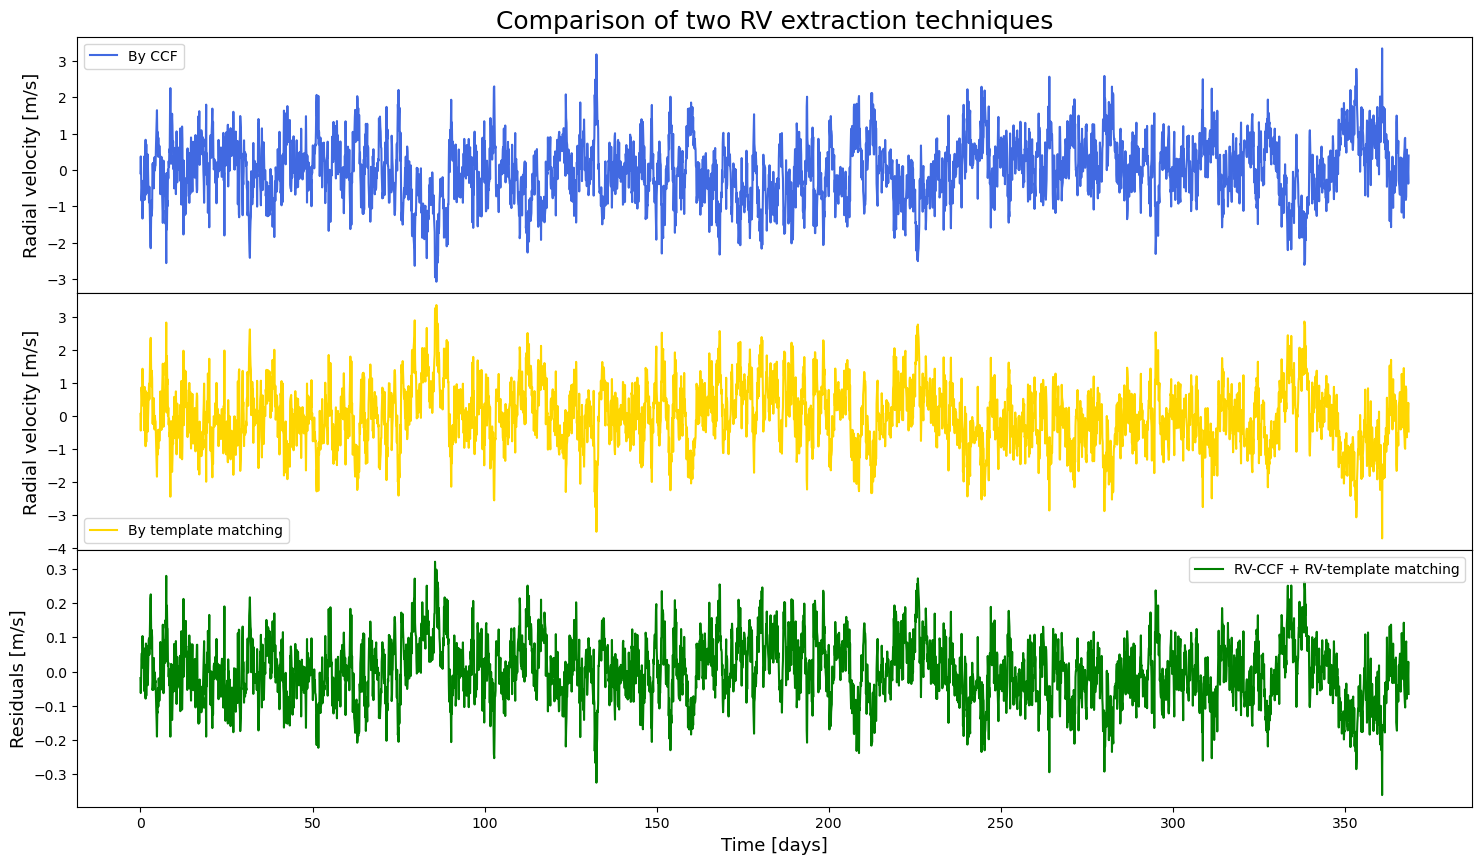

In [13]:
# plot RV
fig, axs = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

axs[0].plot(times, rv_ccf, color='royalblue', label='By CCF')
axs[0].set_title('Comparison of two RV extraction techniques', size=18)
axs[0].set_ylabel('Radial velocity [m/s]', size=13)
#axs[0].set_xlim(0, 30)
axs[0].legend()

axs[1].plot(times, rv_tm, color='gold', label='By template matching')
axs[1].set_ylabel('Radial velocity [m/s]', size=13)
axs[1].legend()

axs[2].plot(times, rv_tm + rv_ccf, color='green', label='RV-CCF + RV-template matching')
axs[2].set_xlabel('Time [days]', size=13)
axs[2].set_ylabel('Residuals [m/s]', size=13)
axs[2].legend()

plt.subplots_adjust(hspace=0)
plt.show()

In [14]:
# get multiplicative factor
factor = rv_tm / rv_ccf
print(np.mean(factor), np.median(factor), np.std(factor))

-1.160555708708268 -1.1040211343759334 2.87991715422945


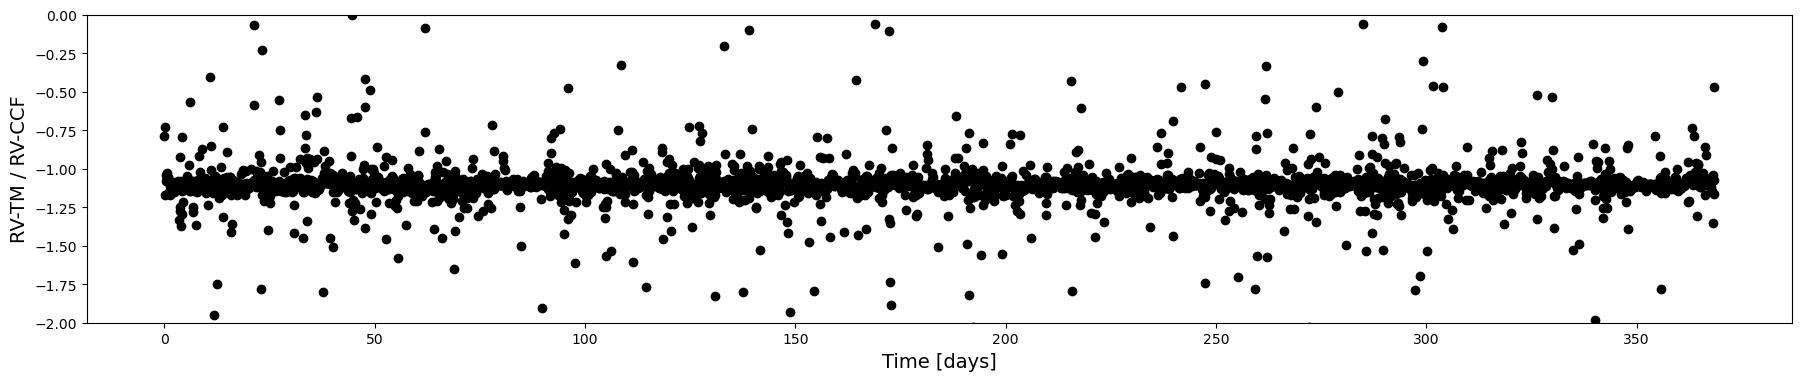

In [15]:
# multiplicative factor between RV-TM and RV-CCF over time
fig, ax = plt.subplots(figsize=(22, 4))
ax.plot(times, factor, 'ko')
ax.set_xlabel('Time [days]', size=14)
ax.set_ylabel('RV-TM / RV-CCF', size=14)
ax.set_ylim(-2, 0)
plt.show()

In [16]:
# try different values of C_0
list_C = np.logspace(1, 4, 4)
RV_tm = []  # RV over time for each value of C_0
for i in list_C:  # iterate over values of C_0
    v = []
    for k in range(len(data_spectra)):  # iterate over spectra
        v.append(t.calculate_rv(wl, mean_spec, data_spectra[k], i))  # save RV of each spectrum
    v = np.array(v)
    RV_tm.append(v)
RV_tm = np.array(RV_tm)

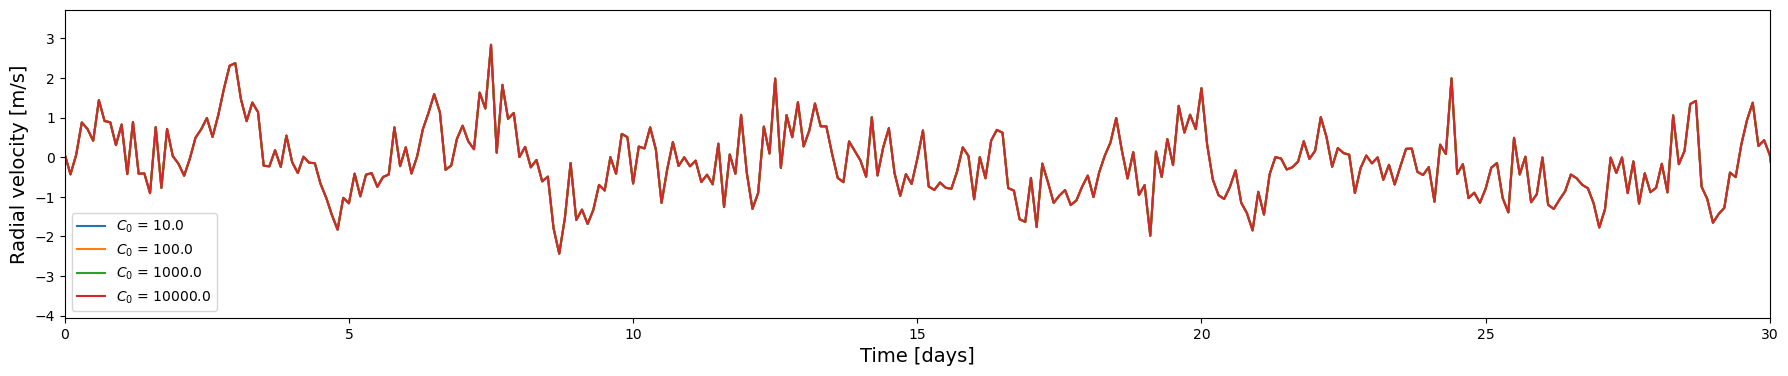

In [17]:
fig, ax = plt.subplots(figsize=(22, 4))
for i in range(len(RV_tm)):
    ax.plot(times, RV_tm[i], label=r'$C_0$ = '+str(list_C[i]))
    ax.set_xlabel('Time [days]', size=14)
    ax.set_ylabel('Radial velocity [m/s]', size=14)
    ax.legend()
ax.set_xlim(0, 30)
plt.show()

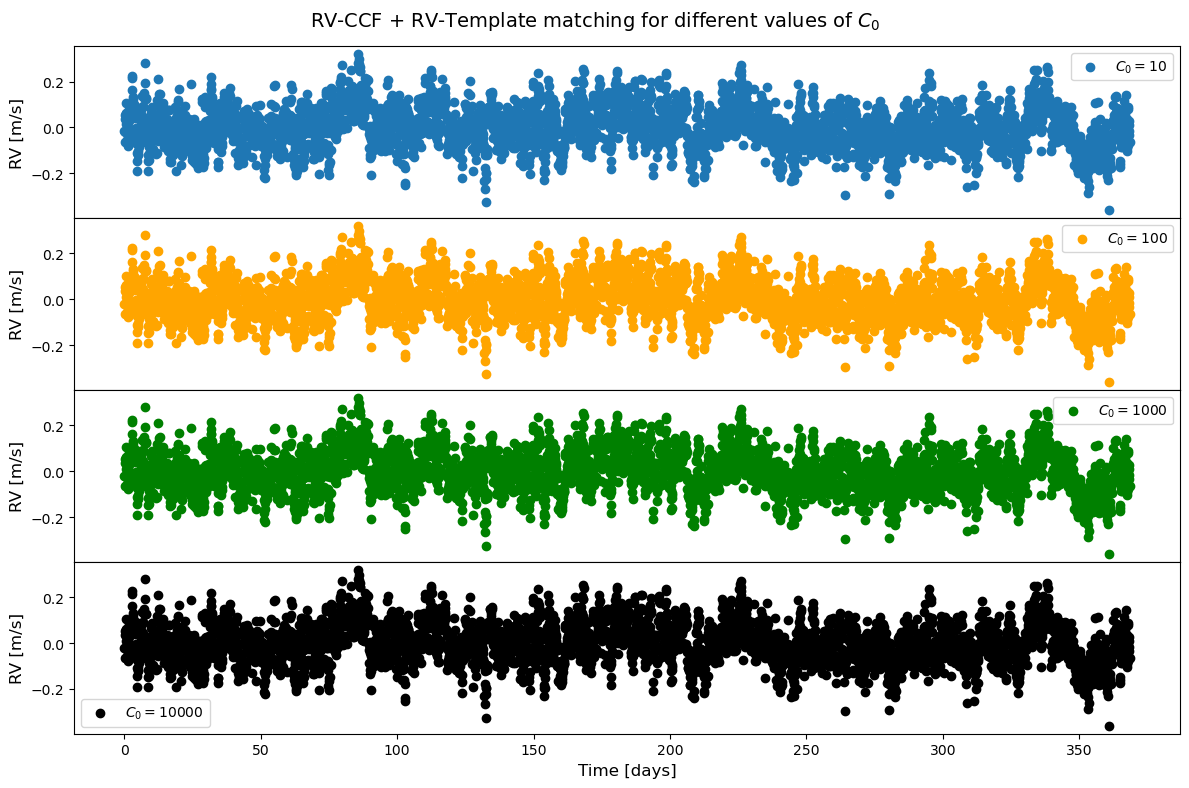

In [18]:
# RV-CCF + RV-Template matching for different values of C_0
fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
fig.suptitle(r'RV-CCF + RV-Template matching for different values of $C_0$', size=14)
axs[0].scatter(times, rv_ccf + RV_tm[0], label=r'$C_0=10$')
axs[0].set_ylabel('RV [m/s]', size=12)
axs[0].legend()

axs[1].scatter(times, rv_ccf + RV_tm[1], color='orange', label=r'$C_0=100$')
axs[1].set_ylabel('RV [m/s]', size=12)
axs[1].legend()

axs[2].scatter(times, rv_ccf + RV_tm[2], color='green', label=r'$C_0=1000$')
axs[2].set_ylabel('RV [m/s]', size=12)
axs[2].legend()

axs[3].scatter(times, rv_ccf + RV_tm[3], color='black', label=r'$C_0=10000$')
axs[3].set_xlabel('Time [days]', size=12)
axs[3].set_ylabel('RV [m/s]', size=12)
axs[3].legend()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

In [19]:
print(np.median(rv_ccf + RV_tm[0]))
print(np.median(rv_ccf + RV_tm[1]))
print(np.median(rv_ccf + RV_tm[2]))
print(np.median(rv_ccf + RV_tm[3]))

-0.0013983237408657125
-0.0013364446349801475
-0.001315802652296319
-0.001309210782564768


In [20]:
np.median(rv_ccf + RV_tm[3]) > np.median(rv_ccf + RV_tm[0])

np.True_

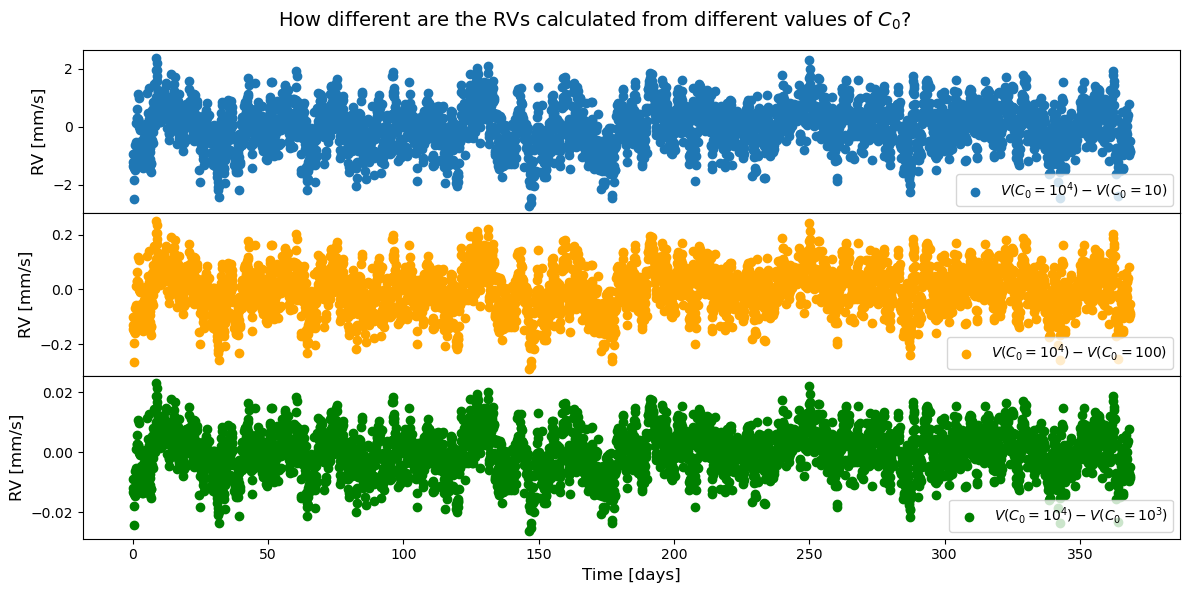

In [21]:
# residuals: the differences between RVs calculated with different values of C_0 are small, of the order of mm/s or smaller
fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
fig.suptitle(r'How different are the RVs calculated from different values of $C_0$?', size=14)
axs[0].scatter(times, 1000*(RV_tm[3] - RV_tm[0]), label=r'$V(C_0=10^4) - V(C_0=10)$')
axs[0].set_ylabel('RV [mm/s]', size=12)
axs[0].legend()

axs[1].scatter(times, 1000*(RV_tm[3] - RV_tm[1]), color='orange', label=r'$V(C_0=10^4) - V(C_0=100)$')
axs[1].set_ylabel('RV [mm/s]', size=12)
axs[1].legend()

axs[2].scatter(times, 1000*(RV_tm[3] - RV_tm[2]), color='green', label=r'$V(C_0=10^4) - V(C_0=10^3)$')
axs[2].set_ylabel('RV [mm/s]', size=12)
axs[2].set_xlabel('Time [days]', size=12)
axs[2].legend()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

## Calculate RV by CCF

In [22]:
#lambda_ref = wl[np.argmin(mean_spec)]  # pick a reference wavelength: I choose the one corresponding to the minimum flux of the reference spectrum
#delta_lambda = wl - lambda_ref  # Angstrom
#vels = c * delta_lambda / wl  # m / s
delta_vel = np.linspace(-5, 5, 201)  # define RV grid
lambda_vr = np.array([t.calculate_lambda_vr(wl, v) for v in delta_vel])  # wavelength grid for each v

In [23]:
# interpolate flux over lambda_vr to fit the originl wavelength grid (wl)
shifted_mask = []  # list of shifted masks, corresponding to each delta_vel
for wl_grid in lambda_vr:  # iterate over wavelength grids
    shifted_mask.append(np.interp(wl, wl_grid, mean_spec))
shifted_mask = np.array(shifted_mask)

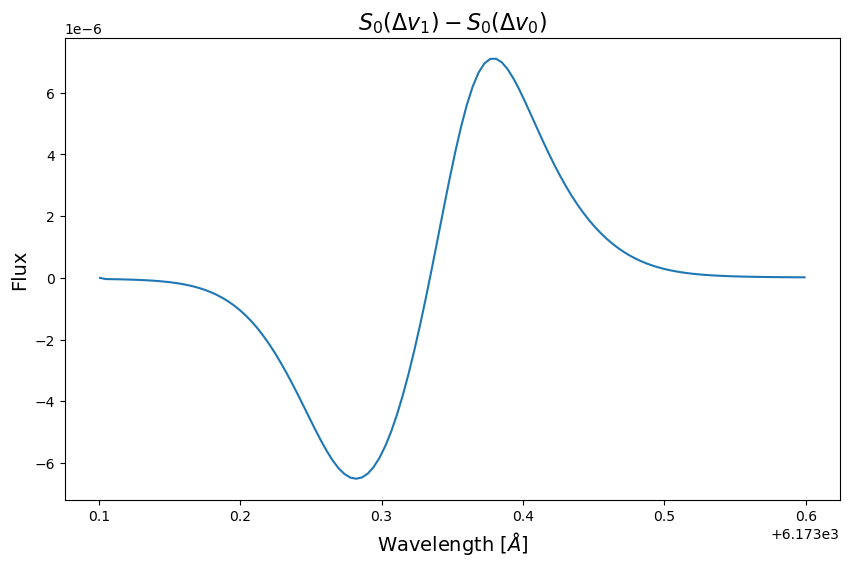

In [24]:
# are the shifted masks different from each other?
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wl, shifted_mask[1] - shifted_mask[0])
ax.set_title(r'$S_0(\Delta v_1) - S_0(\Delta v_0)$', size=16)
ax.set_xlabel(r'Wavelength [$\AA$]', size=14)
ax.set_ylabel('Flux', size=14)
plt.show()

In [25]:
# calculate CCF between each measured spectrum and the reference spectrum
ccf = []
for j in tqdm(range(len(data_spectra))):  # iterate over measured (simulated) spectra
    ccf.append(np.array(
        [sum(t.cross_correlate(data_spectra[j], shifted_mask[i])) for i in range(len(delta_vel))]  # CCF
        ))
ccf = np.array(ccf)  # 2-dimensional array, each element is a list of CCFs between an observed spectrum and all the shifted masks

100%|██████████| 3686/3686 [00:14<00:00, 255.94it/s]


In [26]:
# fit a gaussian to each CCF
params = []
models = []
for i in tqdm(range(len(ccf))):  # iterate over CCF indices
    params_i, _ = curve_fit(t.gaussian, delta_vel, ccf[i], p0=[max(ccf[i])- min(ccf[i]), 0, np.std(delta_vel), np.max(ccf[i])])  # fit a gaussian to the CCF and save the parameters
    model_i = t.gaussian(delta_vel, params_i[0], params_i[1], params_i[2], params_i[3])  # calculate the model using the obtained parameters
    params.append(params_i)  # save parameters
    models.append(model_i)  # save model
params = np.array(params)
models = np.array(models)
mean_vels = params[:, 1]  # recover the position of the peak of each gaussian

  0%|          | 0/3686 [00:00<?, ?it/s]/tmp/ipykernel_2991927/2715889321.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  params_i, _ = curve_fit(t.gaussian, delta_vel, ccf[i], p0=[max(ccf[i])- min(ccf[i]), 0, np.std(delta_vel), np.max(ccf[i])])  # fit a gaussian to the CCF and save the parameters
100%|██████████| 3686/3686 [00:08<00:00, 441.05it/s]


In [27]:
np.mean(delta_vel), np.std(delta_vel)

(np.float64(1.414015394547463e-16), np.float64(2.9011491975882016))

In [28]:
params[0]

array([3.09889131e-07, 5.45433292e-02, 7.00830403e+00, 9.99999691e-01])

In [29]:
9e-1

0.9

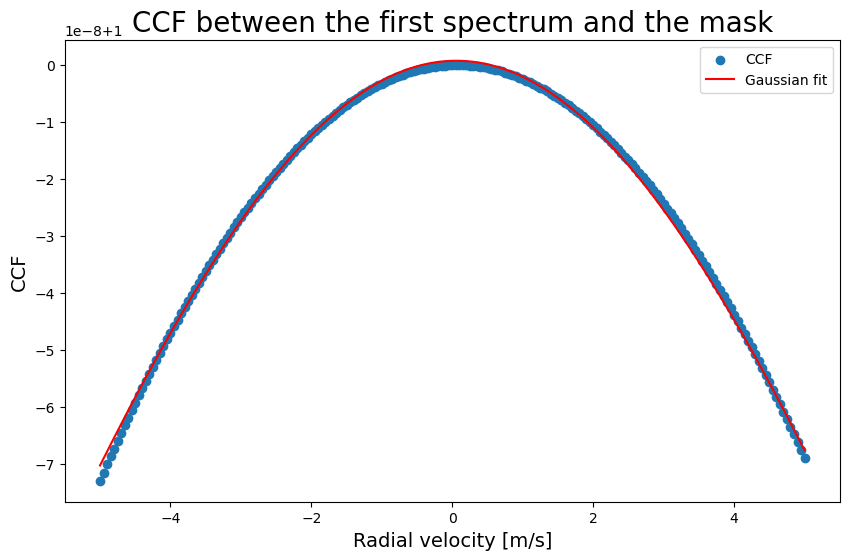

In [30]:
# plot example
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(delta_vel, ccf[0], label='CCF')
ax.plot(delta_vel, models[0], color='r', label='Gaussian fit')
#ax.axvline(mean_vels[0])
ax.set_title('CCF between the first spectrum and the mask', size=20)
ax.set_xlabel('Radial velocity [m/s]', size=14)
ax.set_ylabel('CCF', size=14)
ax.legend()
#ax.set_xlim(-5, 5)
plt.show()

In [31]:
mean_vels

array([ 0.05454333, -0.44583731,  0.03279622, ..., -0.00169333,
        0.41512135, -0.47882986], shape=(3686,))

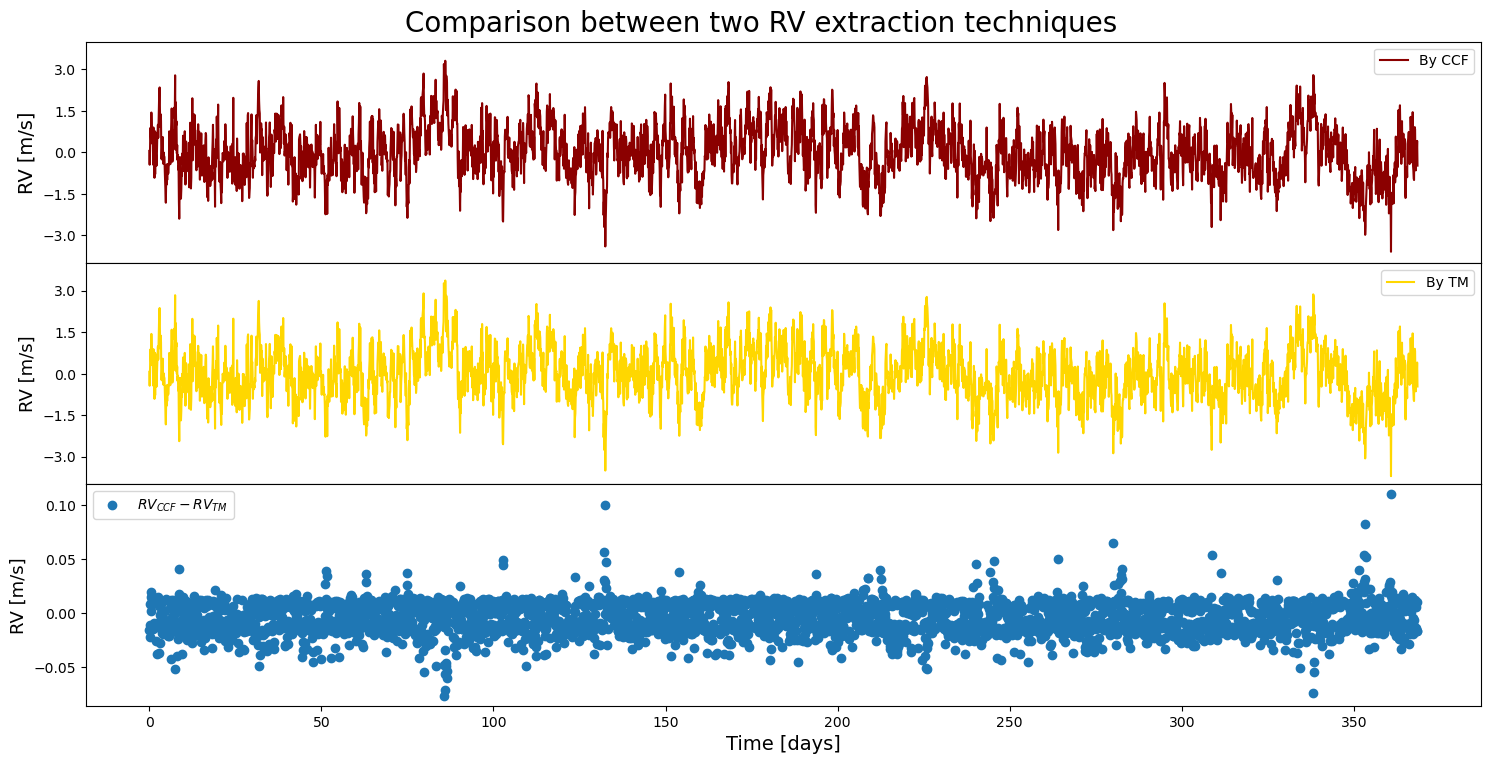

In [32]:
# plot RV
fig, axs = plt.subplots(3, 1, figsize=(18, 8), sharex=True)
fig.suptitle('Comparison between two RV extraction techniques', size=20)

axs[0].plot(times, mean_vels, color='darkred', label='By CCF')
axs[0].set_ylabel('RV [m/s]', size=14)
axs[0].set_ylim(-4, 4)
axs[0].set_yticks([-3, -1.5, 0, 1.5, 3])
axs[0].legend()

axs[1].plot(times, rv_tm, color='gold', label='By TM')
axs[1].set_ylabel('RV [m/s]', size=13)
axs[1].set_ylim(-4, 4)
axs[1].set_yticks([-3, -1.5, 0, 1.5, 3])
axs[1].legend()

axs[2].scatter(times, mean_vels-rv_tm, label=r'$RV_{CCF} - RV_{TM}$')
axs[2].set_xlabel('Time [days]', size=14)
axs[2].set_ylabel('RV [m/s]', size=13)
axs[2].legend()

plt.subplots_adjust(hspace=0, top=.94)
plt.show()

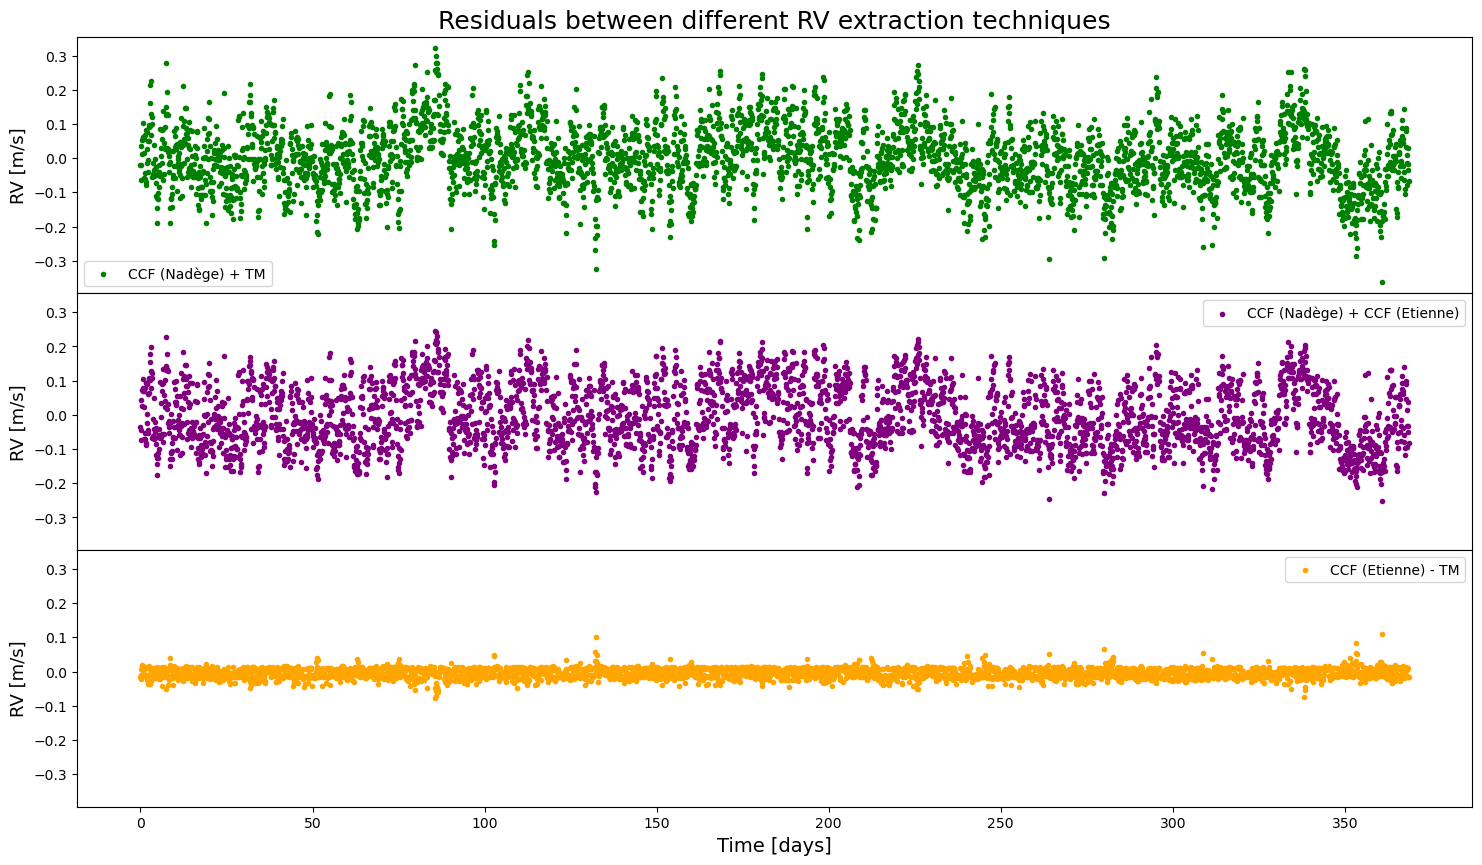

In [33]:
fig, axs = plt.subplots(3, 1, figsize=(18, 10), sharex=True, sharey=True)

axs[0].scatter(times, rv_ccf + rv_tm, marker='.', label='CCF (Nadège) + TM', color='g')
axs[0].set_title('Residuals between different RV extraction techniques', size=18)
axs[0].set_ylabel('RV [m/s]', size=13)
axs[0].legend()

axs[1].scatter(times, mean_vels + rv_ccf, marker='.', label='CCF (Nadège) + CCF (Etienne)', color='purple')
axs[1].set_ylabel('RV [m/s]', size=13)
axs[1].legend()

axs[2].scatter(times, mean_vels - rv_tm, marker='.', label='CCF (Etienne) - TM', color='orange')
axs[2].set_ylabel('RV [m/s]', size=13)
axs[2].legend()
axs[2].set_xlabel('Time [days]', size=14)

plt.subplots_adjust(hspace=0)
plt.show()

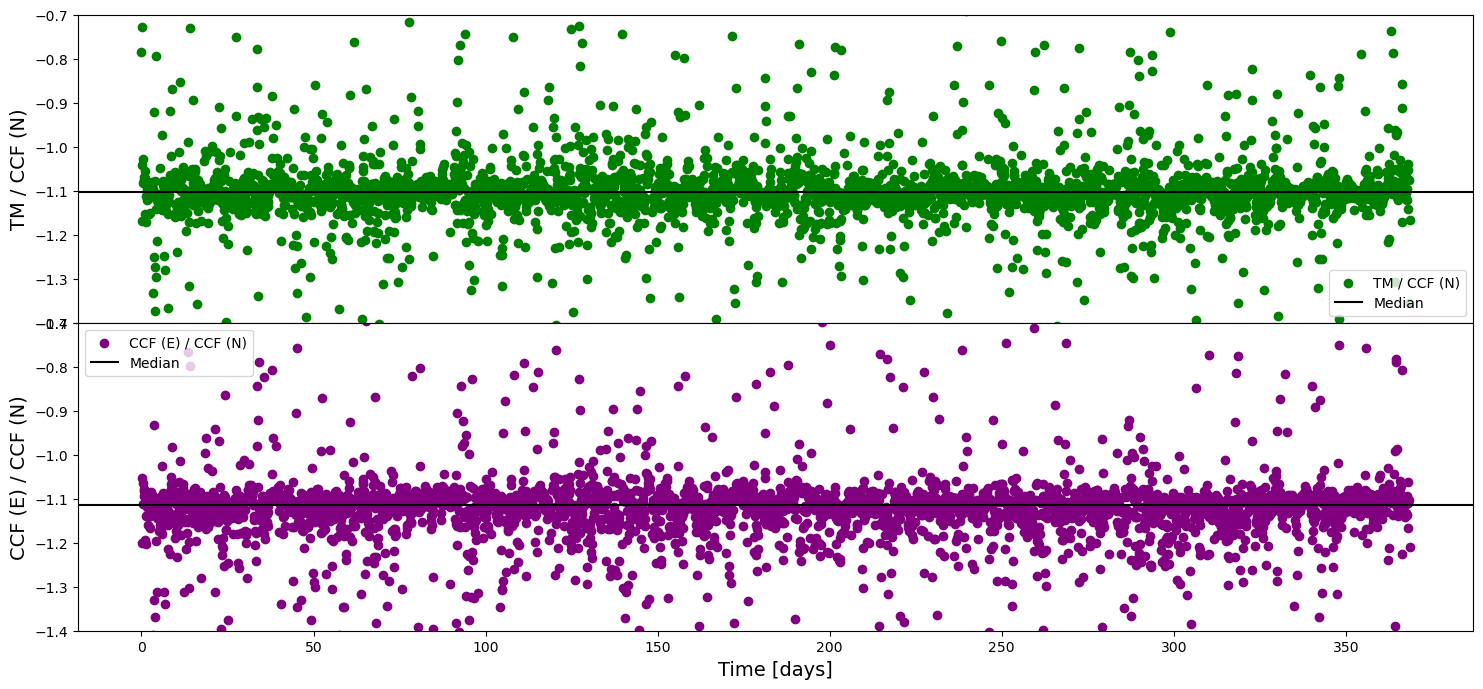

In [34]:
fig, axs = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axs[0].scatter(times, rv_tm / rv_ccf, color='green', label='TM / CCF (N)')
axs[0].axhline(np.median(rv_tm / rv_ccf), color='k', label='Median')
axs[0].set_xlabel('Time [days]', size=14)
axs[0].set_ylabel('TM / CCF (N)', size=14)
axs[0].set_ylim(-1.4, -.7)
axs[0].legend()

axs[1].scatter(times, mean_vels / rv_ccf, color='purple', label='CCF (E) / CCF (N)')
axs[1].axhline(np.median(mean_vels / rv_ccf), color='k', label='Median')
axs[1].set_xlabel('Time [days]', size=14)
axs[1].set_ylabel('CCF (E) / CCF (N)', size=14)
axs[1].set_ylim(-1.4, -.7)
axs[1].legend()

plt.subplots_adjust(hspace=0)
plt.show()

In [35]:
print(f'CCF (E) / CCF (N) median is {np.median(mean_vels / rv_ccf)}')
print(f'TM / CCF (N) median is {np.median(rv_tm / rv_ccf)}')

CCF (E) / CCF (N) median is -1.1141418679252126
TM / CCF (N) median is -1.1040211343759334


In [36]:
rv_ccfE = mean_vels

## RV Periodograms

### Periodograms

In [37]:
times_sec = times * 86400  # time in seconds

# power spectra in m^2/s^2/Hz
ft_ccf, ps_ccf, freq_hz = t.calculate_periodogram(times_sec, rv_ccf)
ft_ccfE, ps_ccfE, freq_hz = t.calculate_periodogram(times_sec, rv_ccfE)
ft_tm, ps_tm, freq_hz = t.calculate_periodogram(times_sec, rv_tm)

freq_days = freq_hz * 86400
mask = freq_days > 0

In [38]:
std_ccf = np.std(ps_ccf)
std_ccfE = np.std(ps_ccfE)
std_tm = np.std(ps_tm)

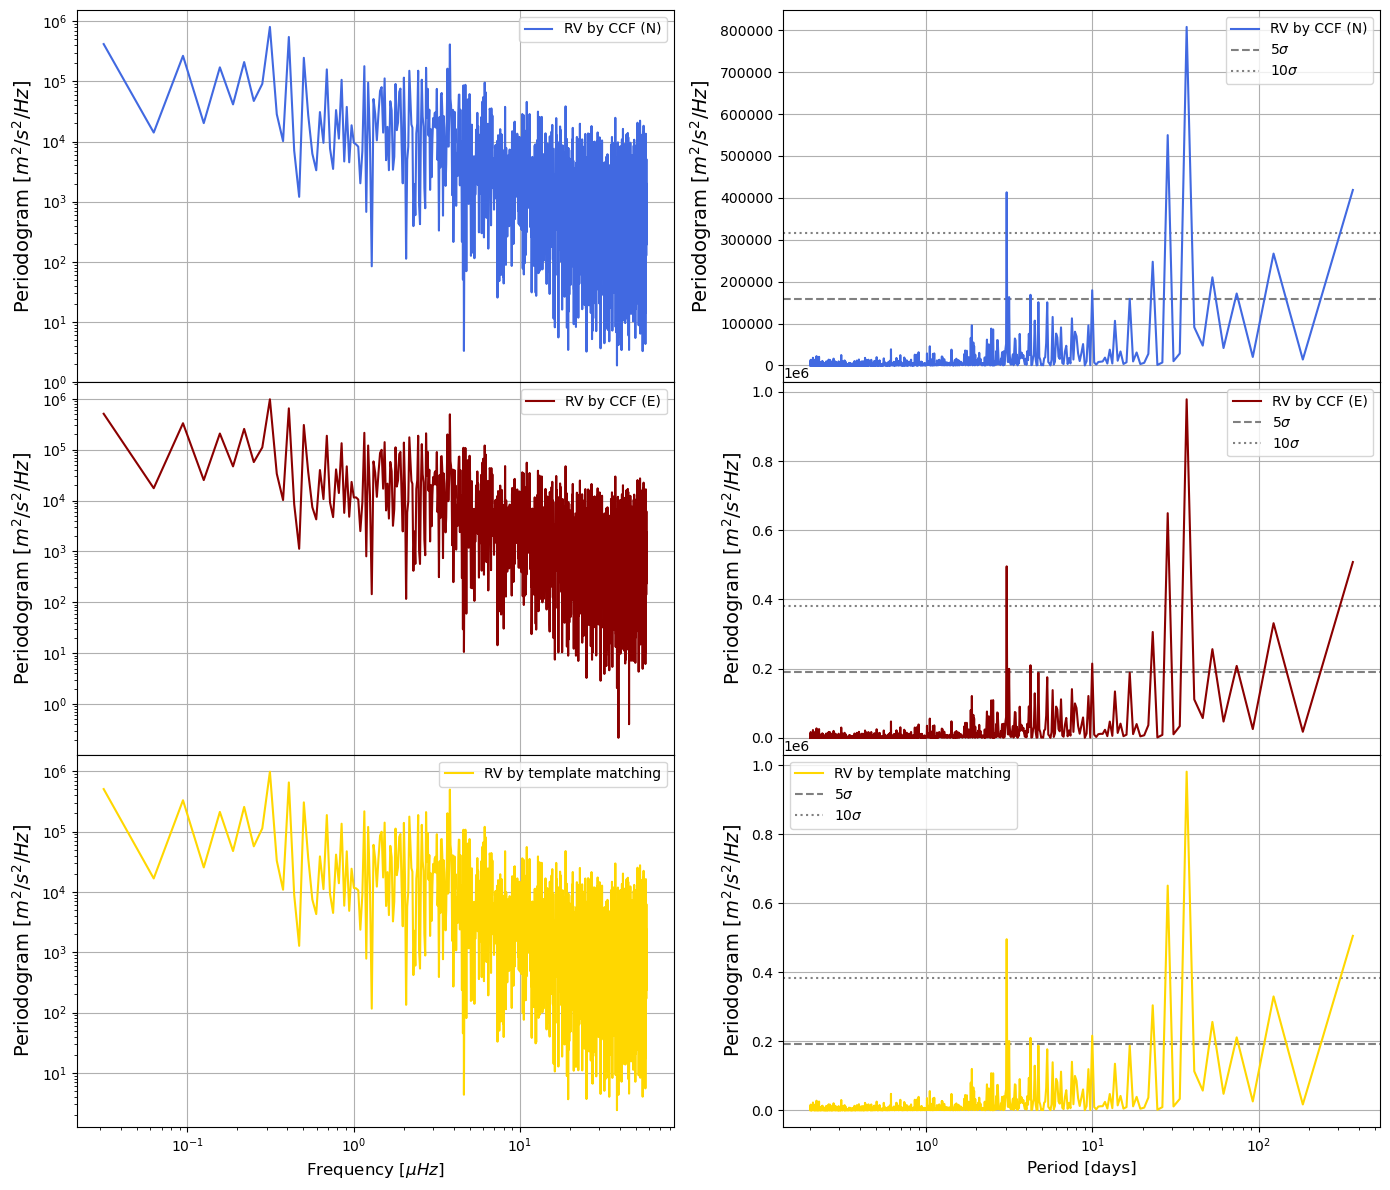

In [39]:
# plot RV periodograms
fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex='col')

# CCF (N)
# Frequency periodogram
axs[0][0].plot(freq_hz[mask] * 10**6, ps_ccf[mask], color='royalblue', label='RV by CCF (N)')
axs[0][0].set_yscale('log')
axs[0][0].set_xscale('log')
axs[0][0].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[0][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0][0].legend()
axs[0][0].grid()

# Periodogram
axs[0][1].plot(1 / freq_days[mask], ps_ccf[mask], color='royalblue', label='RV by CCF (N)')
axs[0][1].axhline(5*std_ccf, linestyle='--', color='gray', label=r'5$\sigma$', zorder=-1)
axs[0][1].axhline(10*std_ccf, linestyle=':', color='gray', label=r'10$\sigma$', zorder=-1)
axs[0][1].set_xscale('log')
axs[0][1].set_xlabel('Period [days]', size=12)
axs[0][1].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[0][1].legend()
axs[0][1].grid()

# CCF (E)
# Frequency periodogram
axs[1][0].plot(freq_hz[mask] * 10**6, ps_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][0].set_yscale('log')
axs[1][0].set_xscale('log')
axs[1][0].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[1][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1][0].legend()
axs[1][0].grid()

# Periodogram
axs[1][1].plot(1 / freq_days[mask], ps_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][1].axhline(5*std_ccfE, linestyle='--', color='gray', label=r'5$\sigma$', zorder=-1)
axs[1][1].axhline(10*std_ccfE, linestyle=':', color='gray', label=r'10$\sigma$', zorder=-1)
axs[1][1].set_xscale('log')
axs[1][1].set_xlabel('Period [days]', size=12)
axs[1][1].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[1][1].legend()
axs[1][1].grid()

# TM
# Frequency periodogram
axs[2][0].plot(freq_hz[mask] * 10**6, ps_tm[mask], color='gold', label='RV by template matching')
axs[2][0].set_yscale('log')
axs[2][0].set_xscale('log')
axs[2][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2][0].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[2][0].legend()
axs[2][0].grid()

# Periodogram
axs[2][1].plot(1 / freq_days[mask], ps_tm[mask], color='gold', label='RV by template matching')
axs[2][1].axhline(5*std_tm, linestyle='--', color='gray', label=r'5$\sigma$', zorder=-1)
axs[2][1].axhline(10*std_tm, linestyle=':', color='gray', label=r'10$\sigma$', zorder=-1)
axs[2][1].set_xscale('log')
#axs[2][1].set_yscale('log')
axs[2][1].set_xlabel('Period [days]', size=12)
axs[2][1].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[2][1].legend()
axs[2][1].grid()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

In [40]:
# split time series into chunks
n_chunks = 19
time_chunks = np.array_split(times_sec, n_chunks)
ccf_chunks  = np.array_split(rv_ccf, n_chunks)
ccfE_chunks  = np.array_split(rv_ccfE, n_chunks)
tm_chunks   = np.array_split(rv_tm, n_chunks)

# do FT for each chunk
periodograms = {}
for i in range(n_chunks):  # iterate over chunk index
    
    # power spectrum
    ft_ccf_i, ps_ccf_i, freq_hz_i = t.calculate_periodogram(time_chunks[i], ccf_chunks[i])
    ft_ccfE_i, ps_ccfE_i, freq_hz_i = t.calculate_periodogram(time_chunks[i], ccfE_chunks[i])
    ft_tm_i, ps_tm_i, freq_hz_i = t.calculate_periodogram(time_chunks[i], tm_chunks[i])

    # mask: positive frequencies
    mask_i = freq_hz_i > 0  # same mask for all periodograms

    periodograms[i] = [ft_ccf_i, ps_ccf_i, ft_ccfE_i, ps_ccfE_i, ft_tm_i, ps_tm_i, freq_hz_i, mask_i]  # save periodogram elements

In [41]:
print(f'Chunk size: {time_chunks[0][-1] / 86400} days.')

Chunk size: 19.3 days.


In [42]:
# mean power spectrum
mean_ps_ccf = np.mean([periodograms[i][1] for i in range(n_chunks)], axis=0)   # from CCF (N)
mean_ps_ccfE = np.mean([periodograms[i][3] for i in range(n_chunks)], axis=0)  # from CCF (E)
mean_ps_tm = np.mean([periodograms[i][5] for i in range(n_chunks)], axis=0)    # from TM

# save important information
m        = periodograms[0][-1]     # mask (same for all)
f_hz     = periodograms[0][-2][m]  # frequency in Hz (same for all)
f_days   = f_hz * 86400            # frequency in days^-1 (same for all)
df       = f_days[1] - f_days[0]
df_hz    = f_hz[1] - f_hz[0]

# apply mask to PS
mean_ps_ccf  = mean_ps_ccf[m]
mean_ps_ccfE = mean_ps_ccfE[m]
mean_ps_tm   = mean_ps_tm[m]

In [43]:
min(f_hz) * 10**6

np.float64(0.5966017563955708)

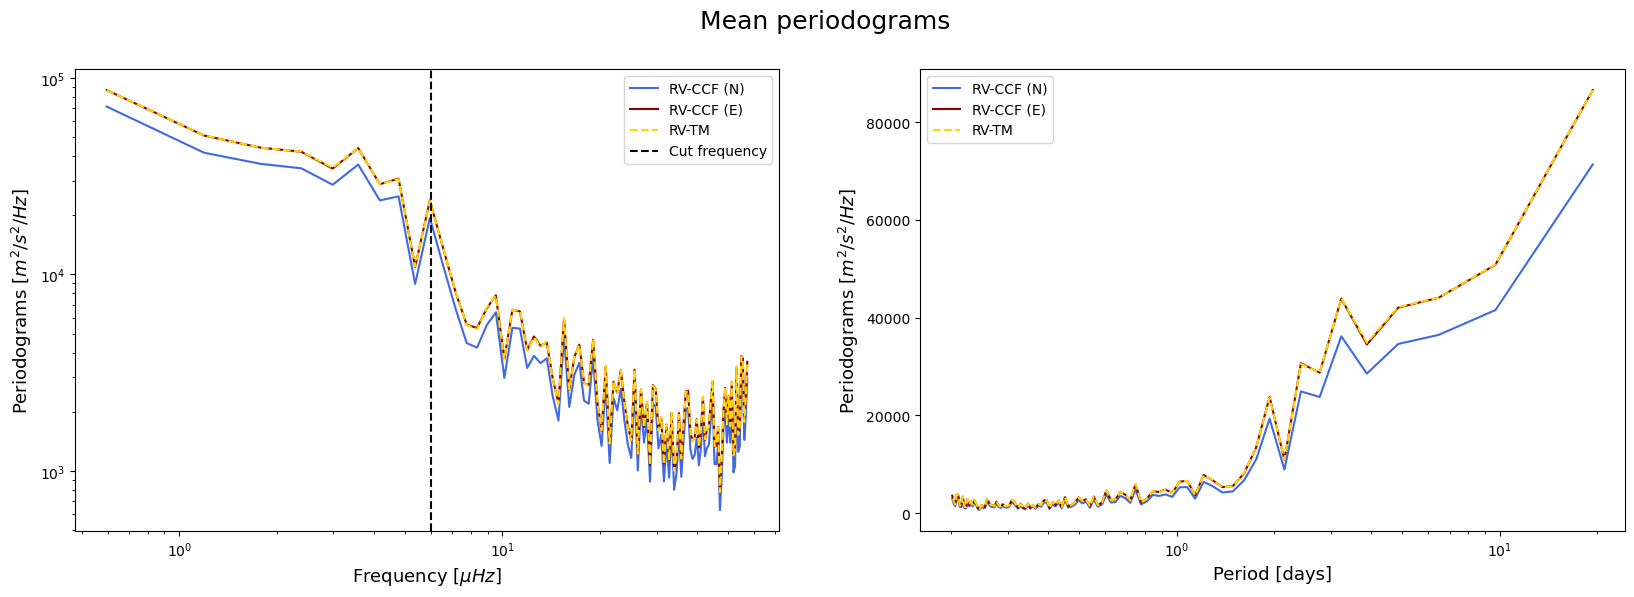

In [44]:
# put as a function of period too
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Mean periodograms', size=18)

axs[0].plot(f_hz * 10**6, mean_ps_ccf, label='RV-CCF (N)', color='royalblue')
axs[0].plot(f_hz * 10**6, mean_ps_ccfE, label='RV-CCF (E)', color='darkred')
axs[0].plot(f_hz * 10**6, mean_ps_tm, label='RV-TM', color='gold', linestyle='--')
axs[0].axvline(6, color='k', linestyle='--', label='Cut frequency')
axs[0].set_xlabel(r'Frequency [$\mu Hz$]', size=13)
axs[0].set_ylabel(r'Periodograms [$m^2/s^2/Hz$]', size=13)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()

axs[1].plot(1 / f_days, mean_ps_ccf, label='RV-CCF (N)', color='royalblue')
axs[1].plot(1 / f_days, mean_ps_ccfE, label='RV-CCF (E)', color='darkred')
axs[1].plot(1 / f_days, mean_ps_tm, label='RV-TM', color='gold', linestyle='--')
#axs[1].axvline(4.8, color='k', linestyle='--', label='Cut frequency')
axs[1].set_xlabel('Period [days]', size=13)
axs[1].set_ylabel(r'Periodograms [$m^2/s^2/Hz$]', size=13)
axs[1].set_xscale('log')
#axs[1].set_yscale('log')
axs[1].legend()

plt.show()

### Harvey fit

MCMC fit explained: https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial.html

In [45]:
# testing mc3 fit on a quadratic function
# quadratic function
def quad(params, x):
    a, b, c = params
    return a * x**2 + b * x + c

# generate data
snr = .1
sigma = 1 / snr
quad_x = np.linspace(-10, 10, 1001)
p_quad = [2, 3, 7]  # parameters
quad_data = quad(p_quad, quad_x) + np.random.normal(0, sigma, len(quad_x))

# fit
p0 = [1, 4, .6]

stepsize = [
    0.1 * p0[0],
    0,           # fix b
    0.1 * p0[2],
]

out = mc3.sample(
    data=quad_data,
    uncert=np.ones_like(quad_data),  # or your actual uncertainties
    func=quad,
    params=p0,  # initial parameters
    indparams=[quad_x],
    sampler='snooker',
    nsamples=5000,
    burnin=1000,
    nchains=4,
    savefile=None,
    stepsize=stepsize
)
bestp = out['bestp']  # best-fit parameters
stdp = out['stdp']  # error for each parameter
posterior = out['posterior']  # MCMC samples


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
  Multi-core Markov-chain Monte Carlo (mc3).
  Version 3.2.1.
  Copyright (c) 2015-2026 Patricio Cubillos and collaborators.
  mc3 is open-source software under the MIT license (see LICENSE).
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

Yippee Ki Yay Monte Carlo!
Start MCMC chains  (Fri Jun 19 15:17:49 2026)

[:         ]  10.6% completed  (Fri Jun 19 15:17:49 2026)
Out-of-bound Trials:
[0 0 0]
Best Parameters: (chisq=108607.8079)
[2.09982533 3.20199268 2.301373  ]

[::        ]  20.2% completed  (Fri Jun 19 15:17:49 2026)
Out-of-bound Trials:
[0 0 0]
Best Parameters: (chisq=99022.8330)
[2.01448022 2.91761211 6.54348987]

[:::       ]  30.4% completed  (Fri Jun 19 15:17:49 2026)
Out-of-bound Trials:
[0 0 0]
Best Parameters: (chisq=98517.4192)
[2.01430544 3.03106138 6.54938025]

[::::      ]  40.7% completed  (Fri Jun 19 15:17:49 2026)
Out-of-bound Trials:
[0 0 0]
Best Parameters: (chisq=9

In [46]:
bestp

array([2.01076944, 3.04141952, 6.72240767])

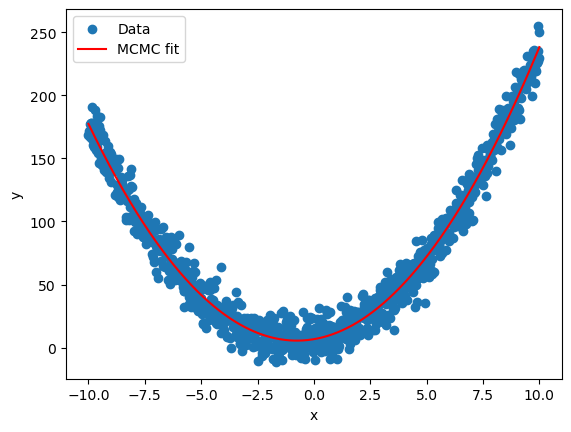

In [47]:
# show data
plt.scatter(quad_x, quad_data, label='Data')
plt.plot(quad_x, quad(bestp, quad_x), color='red', label='MCMC fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [48]:
for i, (val, err) in enumerate(zip(bestp, stdp)):
    print(f"param {i}: {val:.3f} ± {err:.3f}")

param 0: 2.011 ± 0.001
param 1: 3.041 ± 0.005
param 2: 6.722 ± 0.049


In [49]:
# fit Harvey function (for RV-CCF-Nadège)
# initial guess
b0 = 5 / 10**6                                  # b -> turnover frequency from the plot above (where the power starts to decay) [Hz]
a0 = np.std(mean_ps_ccf) * b0                   # a -> amplitude (total power) [m^2/s^2]
c0 = 2                                          # c -> classical value, no units
d0 = np.median(mean_ps_ccf[f_hz * 10**6 > 20])  # d -> median of the noisy part from the plot above  [m^2/s^2/Hz]

p0 = [a0, b0, c0, d0]

pmin = [0, 0, 2, 0]
pmax = [np.inf, np.inf, 4, np.inf]

# least squares fit
params, _ = curve_fit(t.harvey_unpacked, f_hz[1:], mean_ps_ccf[1:], p0=p0)
a_ls, b_ls, c_ls, d_ls = params

In [50]:
x, y = f_hz[1:], mean_ps_ccf[1:]

b0 = 5 / 10**6                     # b -> turnover frequency from the plot above (where the power starts to decay) [Hz]
a0 = np.std(y) * b0                # a -> amplitude (total power) [m^2/s^2]
c0 = 2                             # c -> classical value, no units
d0 = np.median(y[x * 10**6 > 20])  # d -> median of the noisy part from the plot above  [m^2/s^2/Hz]

p0 = [a0, b0, c0, d0]

pmin = [0, 0, 1.9, 0]
pmax = [np.inf, np.inf, 4, np.inf]

stepsize = [
    0.1 * p0[0],
    0.1 * p0[1],
    0.0,           # fix c
    0.1 * p0[3],
]

out = mc3.sample(
    data=y,
    uncert=np.sqrt(np.abs(y)),
    func=t.harvey,
    params=p0,
    indparams=[x],
    sampler='snooker',
    nsamples=50000,
    burnin=1000,
    nchains=4,
    savefile=None,
    pmin=pmin,
    pmax=pmax,
    pstep=stepsize
    
)
bestp = out['bestp']     # best-fit parameters
stdp = out['stdp']       # standard deviation of the parameters
posterior = out['posterior']  # MCMC samples


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
  Multi-core Markov-chain Monte Carlo (mc3).
  Version 3.2.1.
  Copyright (c) 2015-2026 Patricio Cubillos and collaborators.
  mc3 is open-source software under the MIT license (see LICENSE).
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

Yippee Ki Yay Monte Carlo!
Start MCMC chains  (Fri Jun 19 15:19:15 2026)

[:         ]  10.1% completed  (Fri Jun 19 15:19:15 2026)
Out-of-bound Trials:
[23 36 28]
Best Parameters: (chisq=40188.7033)
[2.41062039e-01 2.90586084e-06 1.01333669e+03]

[::        ]  20.0% completed  (Fri Jun 19 15:19:16 2026)
Out-of-bound Trials:
[26 40 34]
Best Parameters: (chisq=40188.6592)
[2.40983022e-01 2.90679226e-06 1.01231515e+03]
Gelman-Rubin statistics for free parameters:
[1.02565333 1.01040988 1.00295829]

[:::       ]  30.0% completed  (Fri Jun 19 15:19:16 2026)
Out-of-bound Trials:
[27 44 38]
Best Parameters: (chisq=40188.6592)
[2.40983022e-01 2.90679226e-06 1.012

In [51]:
a, b, c, d = bestp
a_err, b_err, c_err, d_err = stdp

In [52]:
print(posterior, bestp)

[[4.58719661e-02 4.65584539e-06 1.41128113e+03]
 [4.42623761e-02 4.06598286e-06 1.60475852e+03]
 [4.42623761e-02 4.06598286e-06 1.60475852e+03]
 ...
 [2.41287832e-01 2.90862742e-06 1.01301740e+03]
 [2.40480892e-01 2.91348254e-06 1.01842221e+03]
 [2.41287832e-01 2.90862742e-06 1.01301740e+03]] [2.40983022e-01 2.90679226e-06 2.00000000e+00 1.01231515e+03]


In [53]:
# get percentiles
p16 = np.percentile(posterior, 16, axis=0)
p50 = np.percentile(posterior, 50, axis=0)
p84 = np.percentile(posterior, 84, axis=0)

lowers = p50 - p16
uppers = p84 - p50

# must change indices if a parameter is fixed
a_lower = lowers[0]
b_lower = lowers[1]
#c_lower = lowers[2]
d_lower = lowers[2]

a_upper = uppers[0]
b_upper = uppers[1]
#c_upper = uppers[2]
d_upper = uppers[2]

In [54]:
lowers, uppers

(array([5.10689136e-04, 9.95544009e-09, 5.21587735e+00]),
 array([5.09183555e-04, 9.51748202e-09, 5.43706765e+00]))

In [55]:
# print results
print('Harvey fit to CCF periodogram (MCMC):')
print(f'a={a:.2f} ± {a_err:.5f} m^2/s^2 | b = {10**6*b:.4f} ± {10**6*b_err:.4f} muHz | c = {c:.2f} ± {c_err:.4f} | d = {d:.2f} ± {d_err:.2f} m^2/s^2/Hz')

print('\n\nHarvey fit to CCF periodogram (LS):')
print(f'a={a_ls:.2f} m^2/s^2 | b = {b_ls:.2e} Hz | c = {c_ls:.2f} | d = {d_ls:.2f} m^2/s^2/Hz')

Harvey fit to CCF periodogram (MCMC):
a=0.24 ± 0.00050 m^2/s^2 | b = 2.9068 ± 0.0096 muHz | c = 2.00 ± 0.0000 | d = 1012.32 ± 5.17 m^2/s^2/Hz


Harvey fit to CCF periodogram (LS):
a=0.20 m^2/s^2 | b = 4.84e-06 Hz | c = 3.62 | d = 1716.00 m^2/s^2/Hz


In [56]:
# calculate model from the parameters and SNR
model_harvey = t.harvey(bestp, f_hz)
#snr_harvey = mean_ps_ccf / model_harvey
snr_harvey = a / b / d

In [57]:
snr_harvey, b

(np.float64(81.89487316874971), np.float64(2.906792261795997e-06))

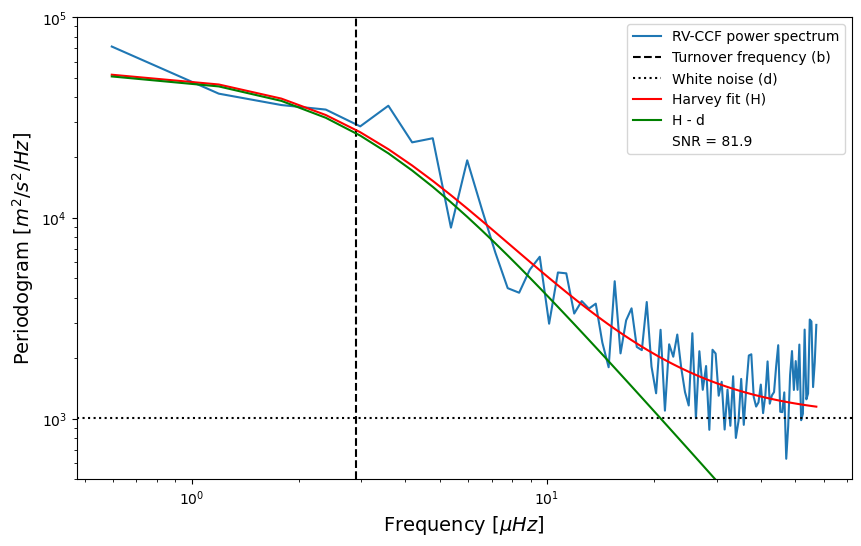

In [58]:
# plot fit
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_hz * 10**6, mean_ps_ccf, label='RV-CCF power spectrum')
ax.axvline(b * 10**6, color='k', linestyle='--', label='Turnover frequency (b)')
ax.axhline(d, color='k', linestyle=':', label='White noise (d)')
ax.loglog(f_hz * 10**6, model_harvey, label='Harvey fit (H)', color='r')
ax.loglog(f_hz * 10**6, model_harvey - d, label='H - d', color='g')
ax.axvline(10, color='w', zorder=-1, label=f'SNR = {snr_harvey:.1f}')
ax.set_xlabel(r'Frequency [$\mu Hz$]', size=14)
ax.set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
ax.set_ylim(5e2, 10**5)
ax.legend()
plt.show()

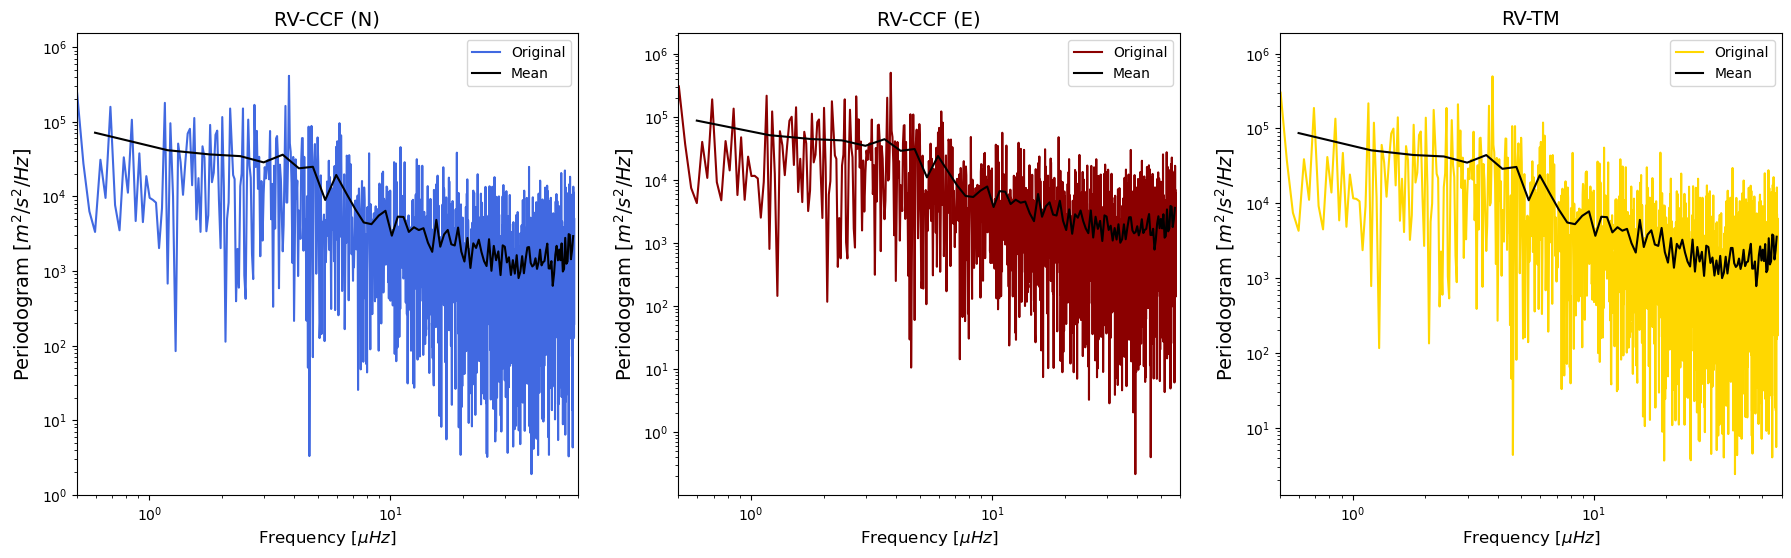

In [59]:
fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# RV-CCF (N)
axs[0].plot(freq_hz[mask] * 10**6, ps_ccf[mask], color='royalblue', label='Original')  # original periodogram
axs[0].plot(f_hz * 10**6, mean_ps_ccf, color='k', label='Mean')  # mean periodogram
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_title('RV-CCF (N)', size=14)
axs[0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[0].set_xlim(.5, 60)
axs[0].legend()

# RV-CCF (E)
axs[1].plot(freq_hz[mask] * 10**6, ps_ccfE[mask], color='darkred', label='Original')  # original periodogram
axs[1].plot(f_hz * 10**6, mean_ps_ccfE, color='k', label='Mean')  # mean periodogram
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_title('RV-CCF (E)', size=14)
axs[1].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[1].set_xlim(.5, 60)
axs[1].legend()

# RV-TM
axs[2].plot(freq_hz[mask] * 10**6, ps_tm[mask], color='gold', label='Original')  # original periodogram
axs[2].plot(f_hz * 10**6, mean_ps_tm, color='k', label='Mean')  # mean periodogram
axs[2].set_yscale('log')
axs[2].set_xscale('log')
axs[2].set_title('RV-TM', size=14)
axs[2].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[2].set_xlim(.5, 60)
axs[2].legend()

plt.show()

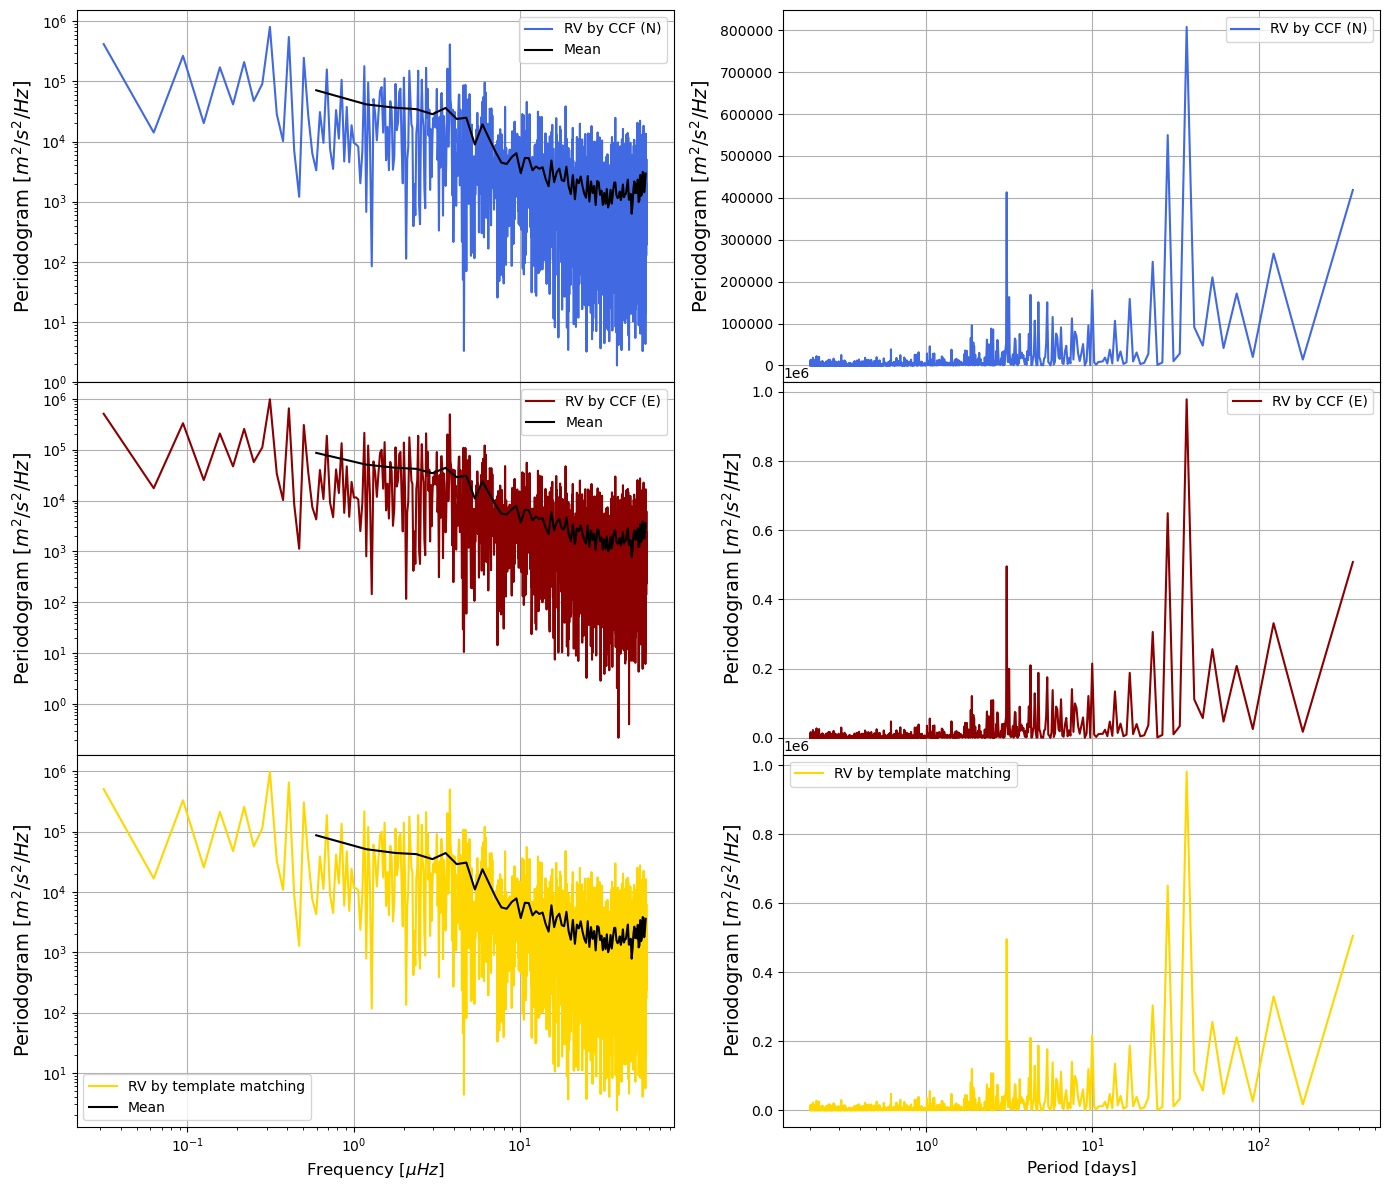

In [60]:
# plot RV periodograms
fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex='col')

# CCF (N)
# Frequency periodogram
axs[0][0].plot(freq_hz[mask] * 10**6, ps_ccf[mask], color='royalblue', label='RV by CCF (N)')
axs[0][0].plot(f_hz * 10**6, mean_ps_ccf, color='k', label='Mean')  # mean periodogram
axs[0][0].set_yscale('log')
axs[0][0].set_xscale('log')
axs[0][0].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[0][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[0][0].legend()
axs[0][0].grid()

# Periodogram
axs[0][1].plot(1 / freq_days[mask], ps_ccf[mask], color='royalblue', label='RV by CCF (N)')
axs[0][1].set_xscale('log')
axs[0][1].set_xlabel('Period [days]', size=12)
axs[0][1].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[0][1].legend()
axs[0][1].grid()

# CCF (E)
# Frequency periodogram
axs[1][0].plot(freq_hz[mask] * 10**6, ps_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][0].plot(f_hz * 10**6, mean_ps_ccfE, color='k', label='Mean')  # mean periodogram
axs[1][0].set_yscale('log')
axs[1][0].set_xscale('log')
axs[1][0].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[1][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[1][0].legend()
axs[1][0].grid()

# Periodogram
axs[1][1].plot(1 / freq_days[mask], ps_ccfE[mask], color='darkred', label='RV by CCF (E)')
axs[1][1].set_xscale('log')
axs[1][1].set_xlabel('Period [days]', size=12)
axs[1][1].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[1][1].legend()
axs[1][1].grid()

# TM
# Frequency periodogram
axs[2][0].plot(freq_hz[mask] * 10**6, ps_tm[mask], color='gold', label='RV by template matching')
axs[2][0].plot(f_hz * 10**6, mean_ps_tm, color='k', label='Mean')  # mean periodogram
axs[2][0].set_yscale('log')
axs[2][0].set_xscale('log')
axs[2][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
axs[2][0].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[2][0].legend()
axs[2][0].grid()

# Periodogram
axs[2][1].plot(1 / freq_days[mask], ps_tm[mask], color='gold', label='RV by template matching')
axs[2][1].set_xscale('log')
#axs[2][1].set_yscale('log')
axs[2][1].set_xlabel('Period [days]', size=12)
axs[2][1].set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
axs[2][1].legend()
axs[2][1].grid()

fig.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

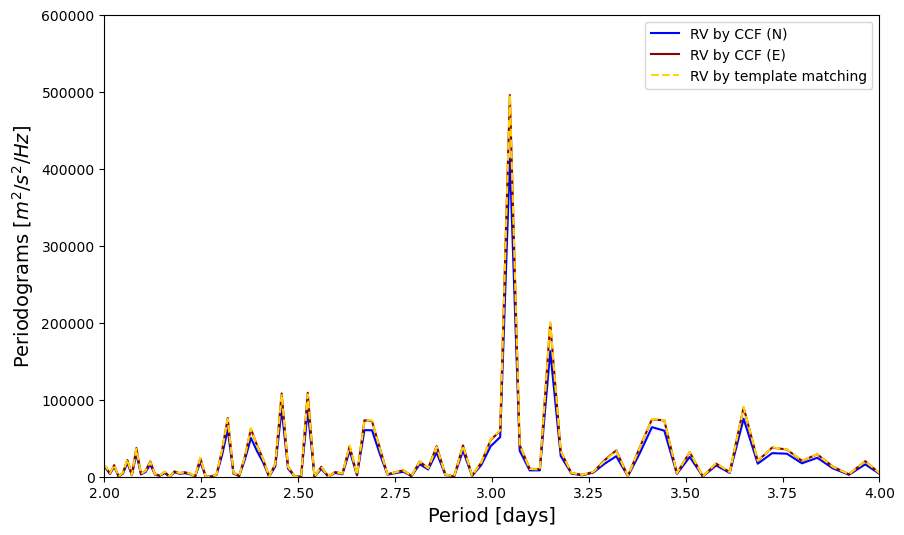

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(1 / freq_days[mask], ps_ccf[mask], color='blue', label='RV by CCF (N)')
ax.plot(1 / freq_days[mask], ps_ccfE[mask], color='darkred', label='RV by CCF (E)')
ax.plot(1 / freq_days[mask], ps_tm[mask], color='gold', label='RV by template matching', linestyle='--')
ax.set_xlabel('Period [days]', size=14)
ax.set_ylabel(r'Periodograms [$m^2/s^2/Hz$]', size=14)
#ax.set_xscale('log')
ax.set_xlim(2, 4)
ax.set_ylim(-.1, 6e5)
ax.legend()

plt.show()

## Apply PCA

In [62]:
# corrected wavelength
lambda_corr = t.calculate_lambda_corr(wl, rv_ccf)

In [63]:
# interpolation to a common reference grid, as lambda_corr is different for each spectrum

resampled_flux = []

for wave, flux in zip(lambda_corr, data_spectra):  # iterate over wavelength, spectrum pairs
    interp_flux = np.interp(wl, wave, flux)  # interpolate the observed spectrum into the reference grid
    resampled_flux.append(interp_flux)  # save

spectra_matrix = np.array(resampled_flux)

In [64]:
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(spectra_matrix)

In [65]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [5.84058761e-01 3.37753042e-01 7.44346744e-02 2.20807852e-03
 1.32671794e-03 1.44220570e-04 4.44046650e-05 1.26668343e-05
 8.10830686e-06 4.93663843e-06 1.60434188e-06 1.25245686e-06
 3.95939414e-07 1.24909119e-07 9.19352324e-08 7.64845279e-08
 1.59823771e-08 1.23543483e-08 1.14953082e-08 1.12403799e-08]


In [66]:
# save loadings and scores
loadings = pca_flux.components_
scores = np.array([pcs[:, i] for i in range(n_components)])

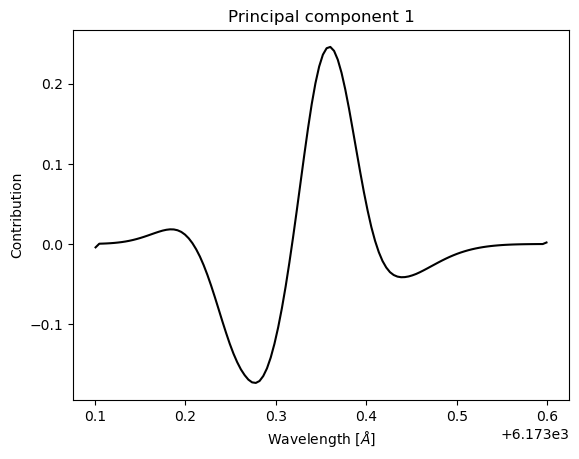

In [67]:
# plot loadings
# plot shows how much each wavelength value (feature) contributes to the variance of a PC
for i in range(1):  # put n_components instead of 1 to see all the plots
    plt.plot(wl, loadings[i], color='k')
    plt.title(f'Principal component {i + 1}', size=12)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel('Contribution')
    plt.show()

In [ ]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
snr = 300
sigma = 1 / snr
mean_maxes = t.calculate_pca_significance(n_realizations, n_components, wl, spectra_matrix, sigma)  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

 30%|███       | 6/20 [00:00<00:00, 29.08it/s]

100%|██████████| 20/20 [00:00<00:00, 25.51it/s]


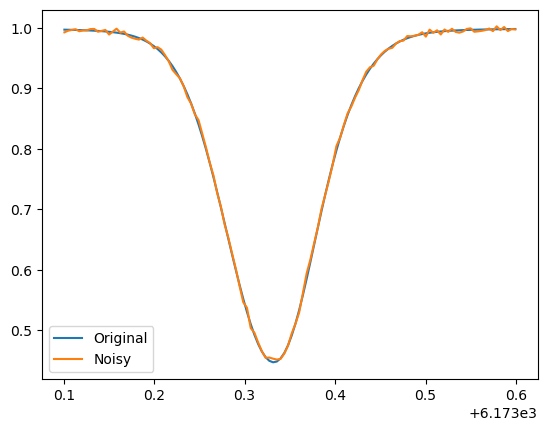

In [73]:
# show noise
spectra_noisy = spectra_matrix + np.random.normal(0, sigma, len(wl))  # add gaussian noise to the original data
plt.plot(wl, spectra_matrix[0], label='Original')
plt.plot(wl, spectra_noisy[0], label='Noisy')
plt.legend()
plt.show()

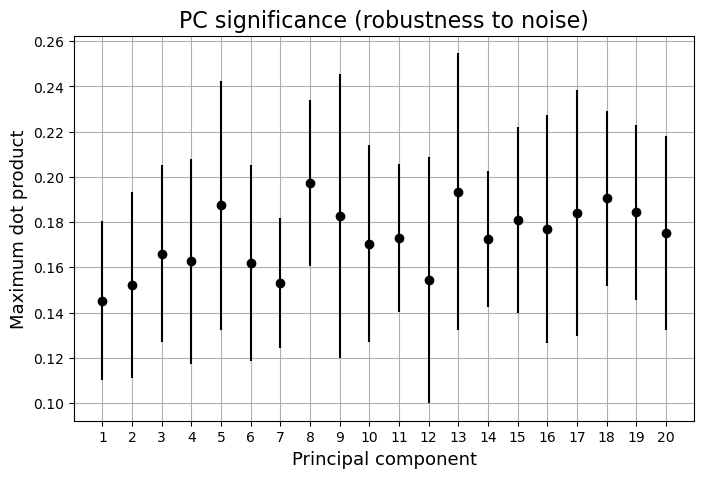

In [74]:
# plot component significance
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', color='k', ecolor='k')
ax.set_title('PC significance (robustness to noise)', size=16)
ax.set_xlabel('Principal component', size=13)
ax.set_ylabel('Maximum dot product', size=13)
ax.set_xticks(np.arange(1, 21, 1))
ax.grid(zorder=-1)
plt.show()

In [74]:
# calculate periodogram and frequencies
pgs = np.array([t.calculate_periodogram(times_sec, scores[i]) for i in range(n_components)])  # calculate periodograms
ft, ps, freq = pgs[:, 0], pgs[:, 1], pgs[:, 2]  # save FT, PS and frequencies

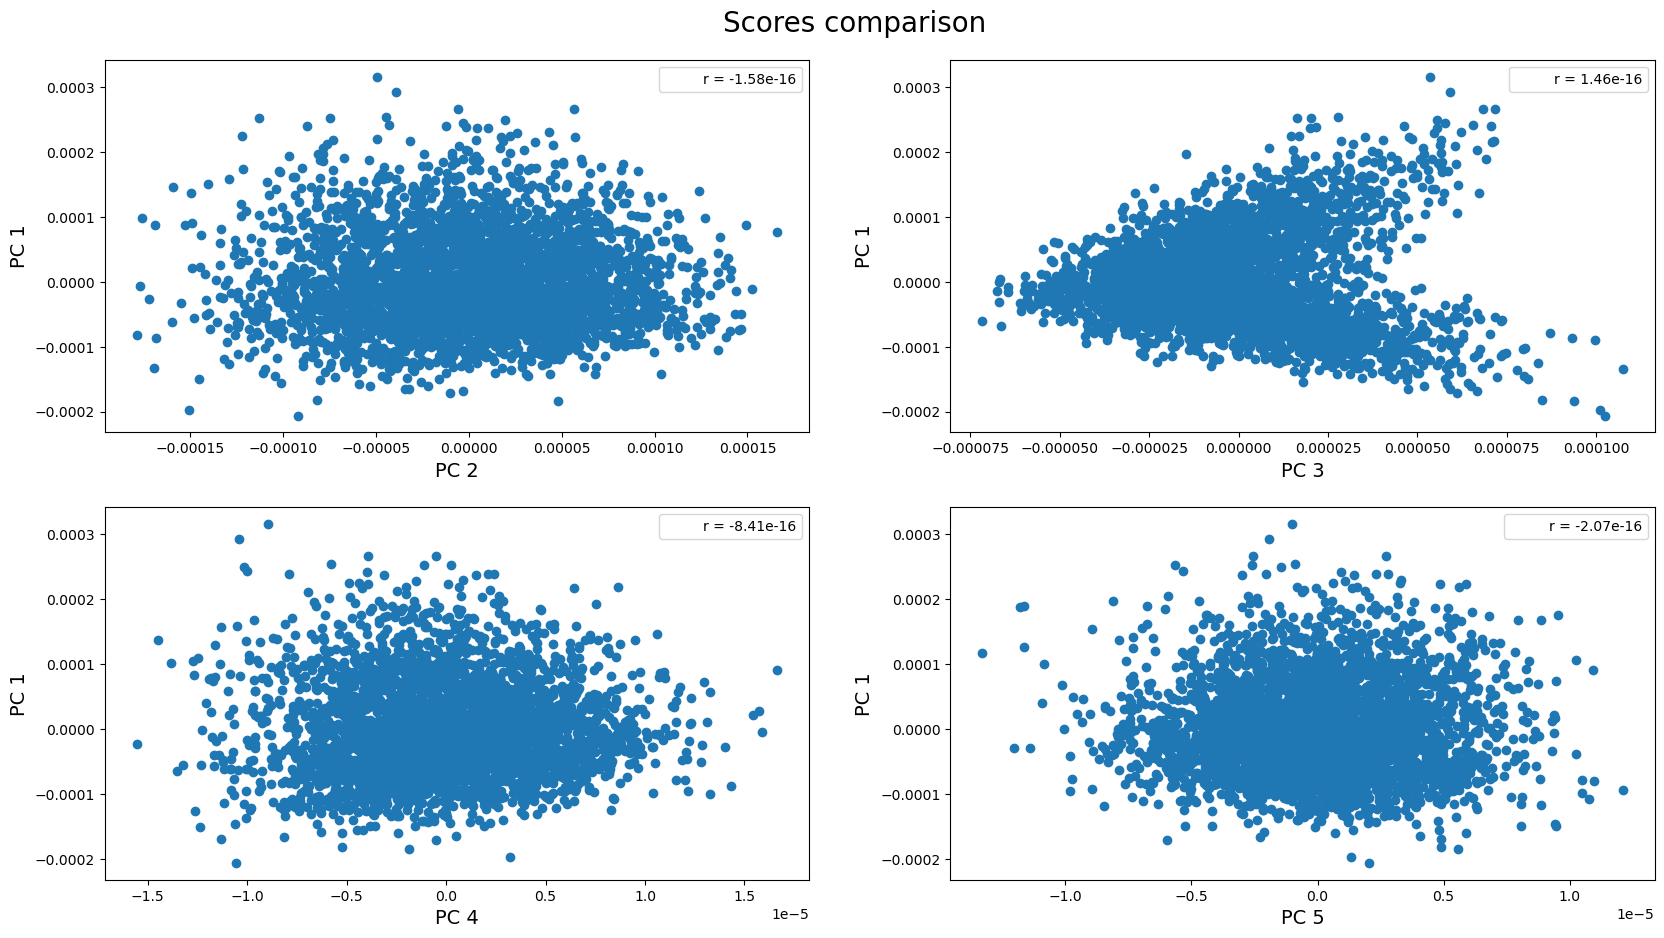

In [75]:
# RV (CCF) as a function of scores

rows = 2
cols = 2
fig, axs = plt.subplots(rows, cols, figsize=(20, 10))
fig.suptitle('Scores comparison', size=20)

r = -1
k = 0
for i in range(rows * cols):
    if i % cols == 0:
        r += 1  # advance to the next column
        k = 0  # reset row
    # RV as a function of scores
    axs[r][k].scatter(scores[i+1], scores[0])
    axs[r][k].axvline(0, color='w', label=f'r = {ss.pearsonr(scores[i+1], scores[0])[0]:.2e}', zorder=-1)
    axs[r][k].set_xlabel(f'PC {i+2}', size=14)
    axs[r][k].set_ylabel('PC 1', size=14)
    axs[r][k].legend()
    k += 1

plt.subplots_adjust(top=.93)
plt.show()

In [76]:
# correlation coefficient between PC1 and PC3
scores1, scores3 = scores[0], scores[2]
corr = ss.pearsonr(scores3, scores1)
corr_p = ss.pearsonr(scores3[scores1 >= 0], scores1[scores1 >= 0])
corr_n = ss.pearsonr(scores3[scores1 < 0], scores1[scores1 < 0])

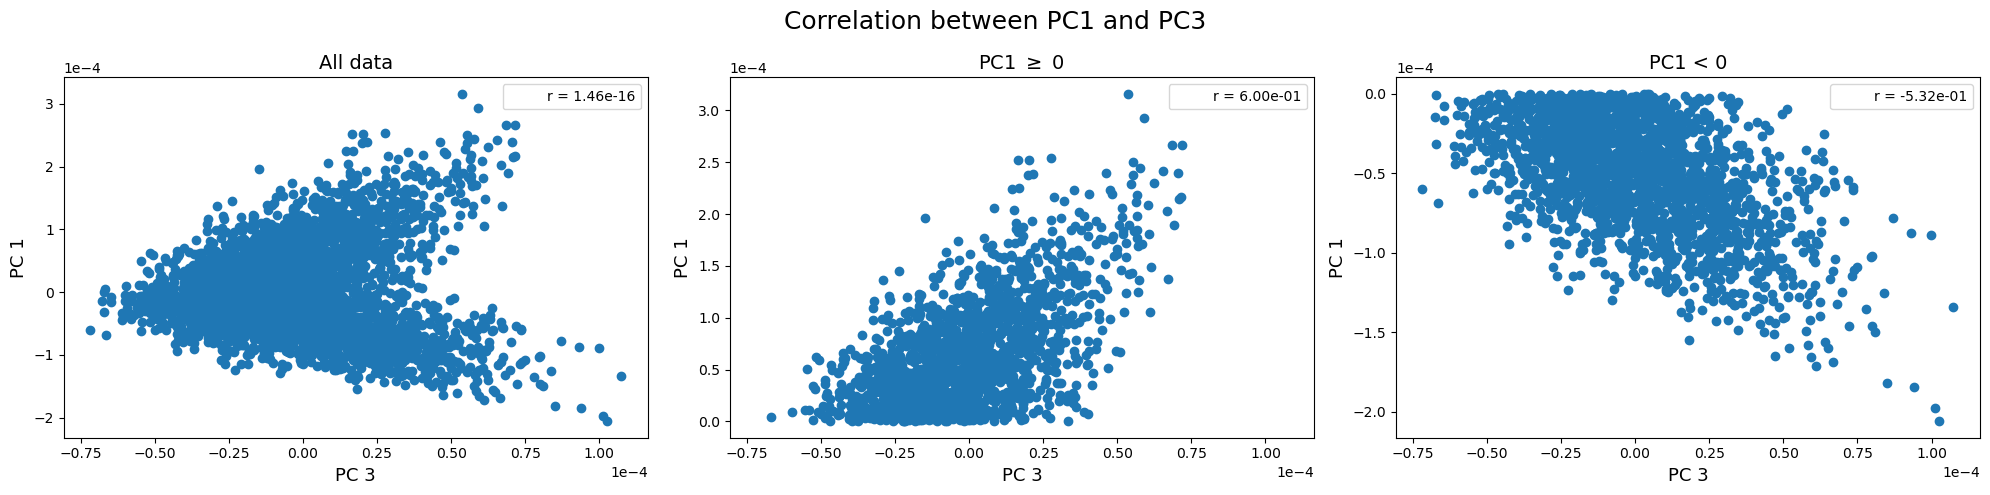

In [77]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True)
fig.suptitle('Correlation between PC1 and PC3', size=18)

axs[0].scatter(scores3, scores1)
axs[0].axvline(0, color='w', label=f'r = {corr[0]:.2e}', zorder=-1)
axs[0].set_title('All data', size=14)

axs[1].scatter(scores3[scores1 >= 0], scores1[scores1 >= 0])
axs[1].axvline(0, color='w', label=f'r = {corr_p[0]:.2e}', zorder=-1)
axs[1].set_title(r'PC1 $\geq$ 0', size=14)

axs[2].scatter(scores3[scores1 < 0], scores1[scores1 < 0])
axs[2].axvline(0, color='w', label=f'r = {corr_n[0]:.2e}', zorder=-1)
axs[2].set_title(r'PC1 < 0', size=14)

for ax in axs:
    ax.set_xlabel('PC 3', size=13)
    ax.set_ylabel('PC 1', size=13)
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    ax.legend()


fig.tight_layout()
plt.show()

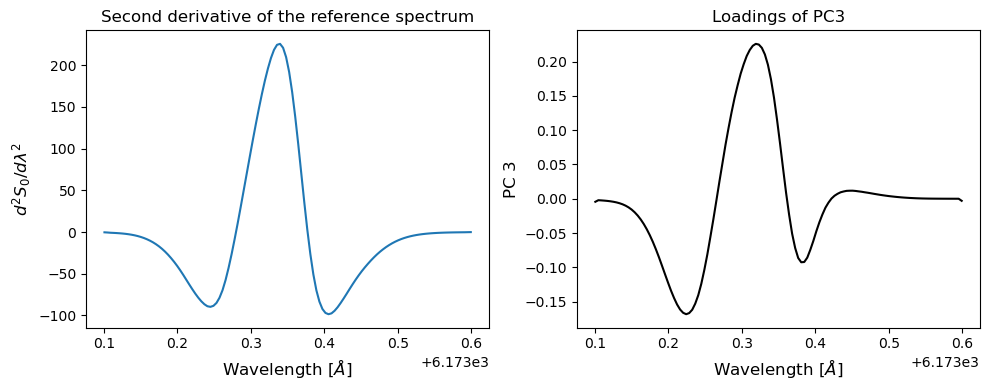

In [78]:
# second derivative vs PC3
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(wl, d2_S0)
axs[0].set_title('Second derivative of the reference spectrum', size=12)
axs[0].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[0].set_ylabel(r'$d^2S_0 / d\lambda^2$', size=12)

axs[1].plot(wl, loadings[2], color='k')
axs[1].set_title('Loadings of PC3', size=12)
axs[1].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[1].set_ylabel('PC 3', size=12)

fig.tight_layout()
plt.show()

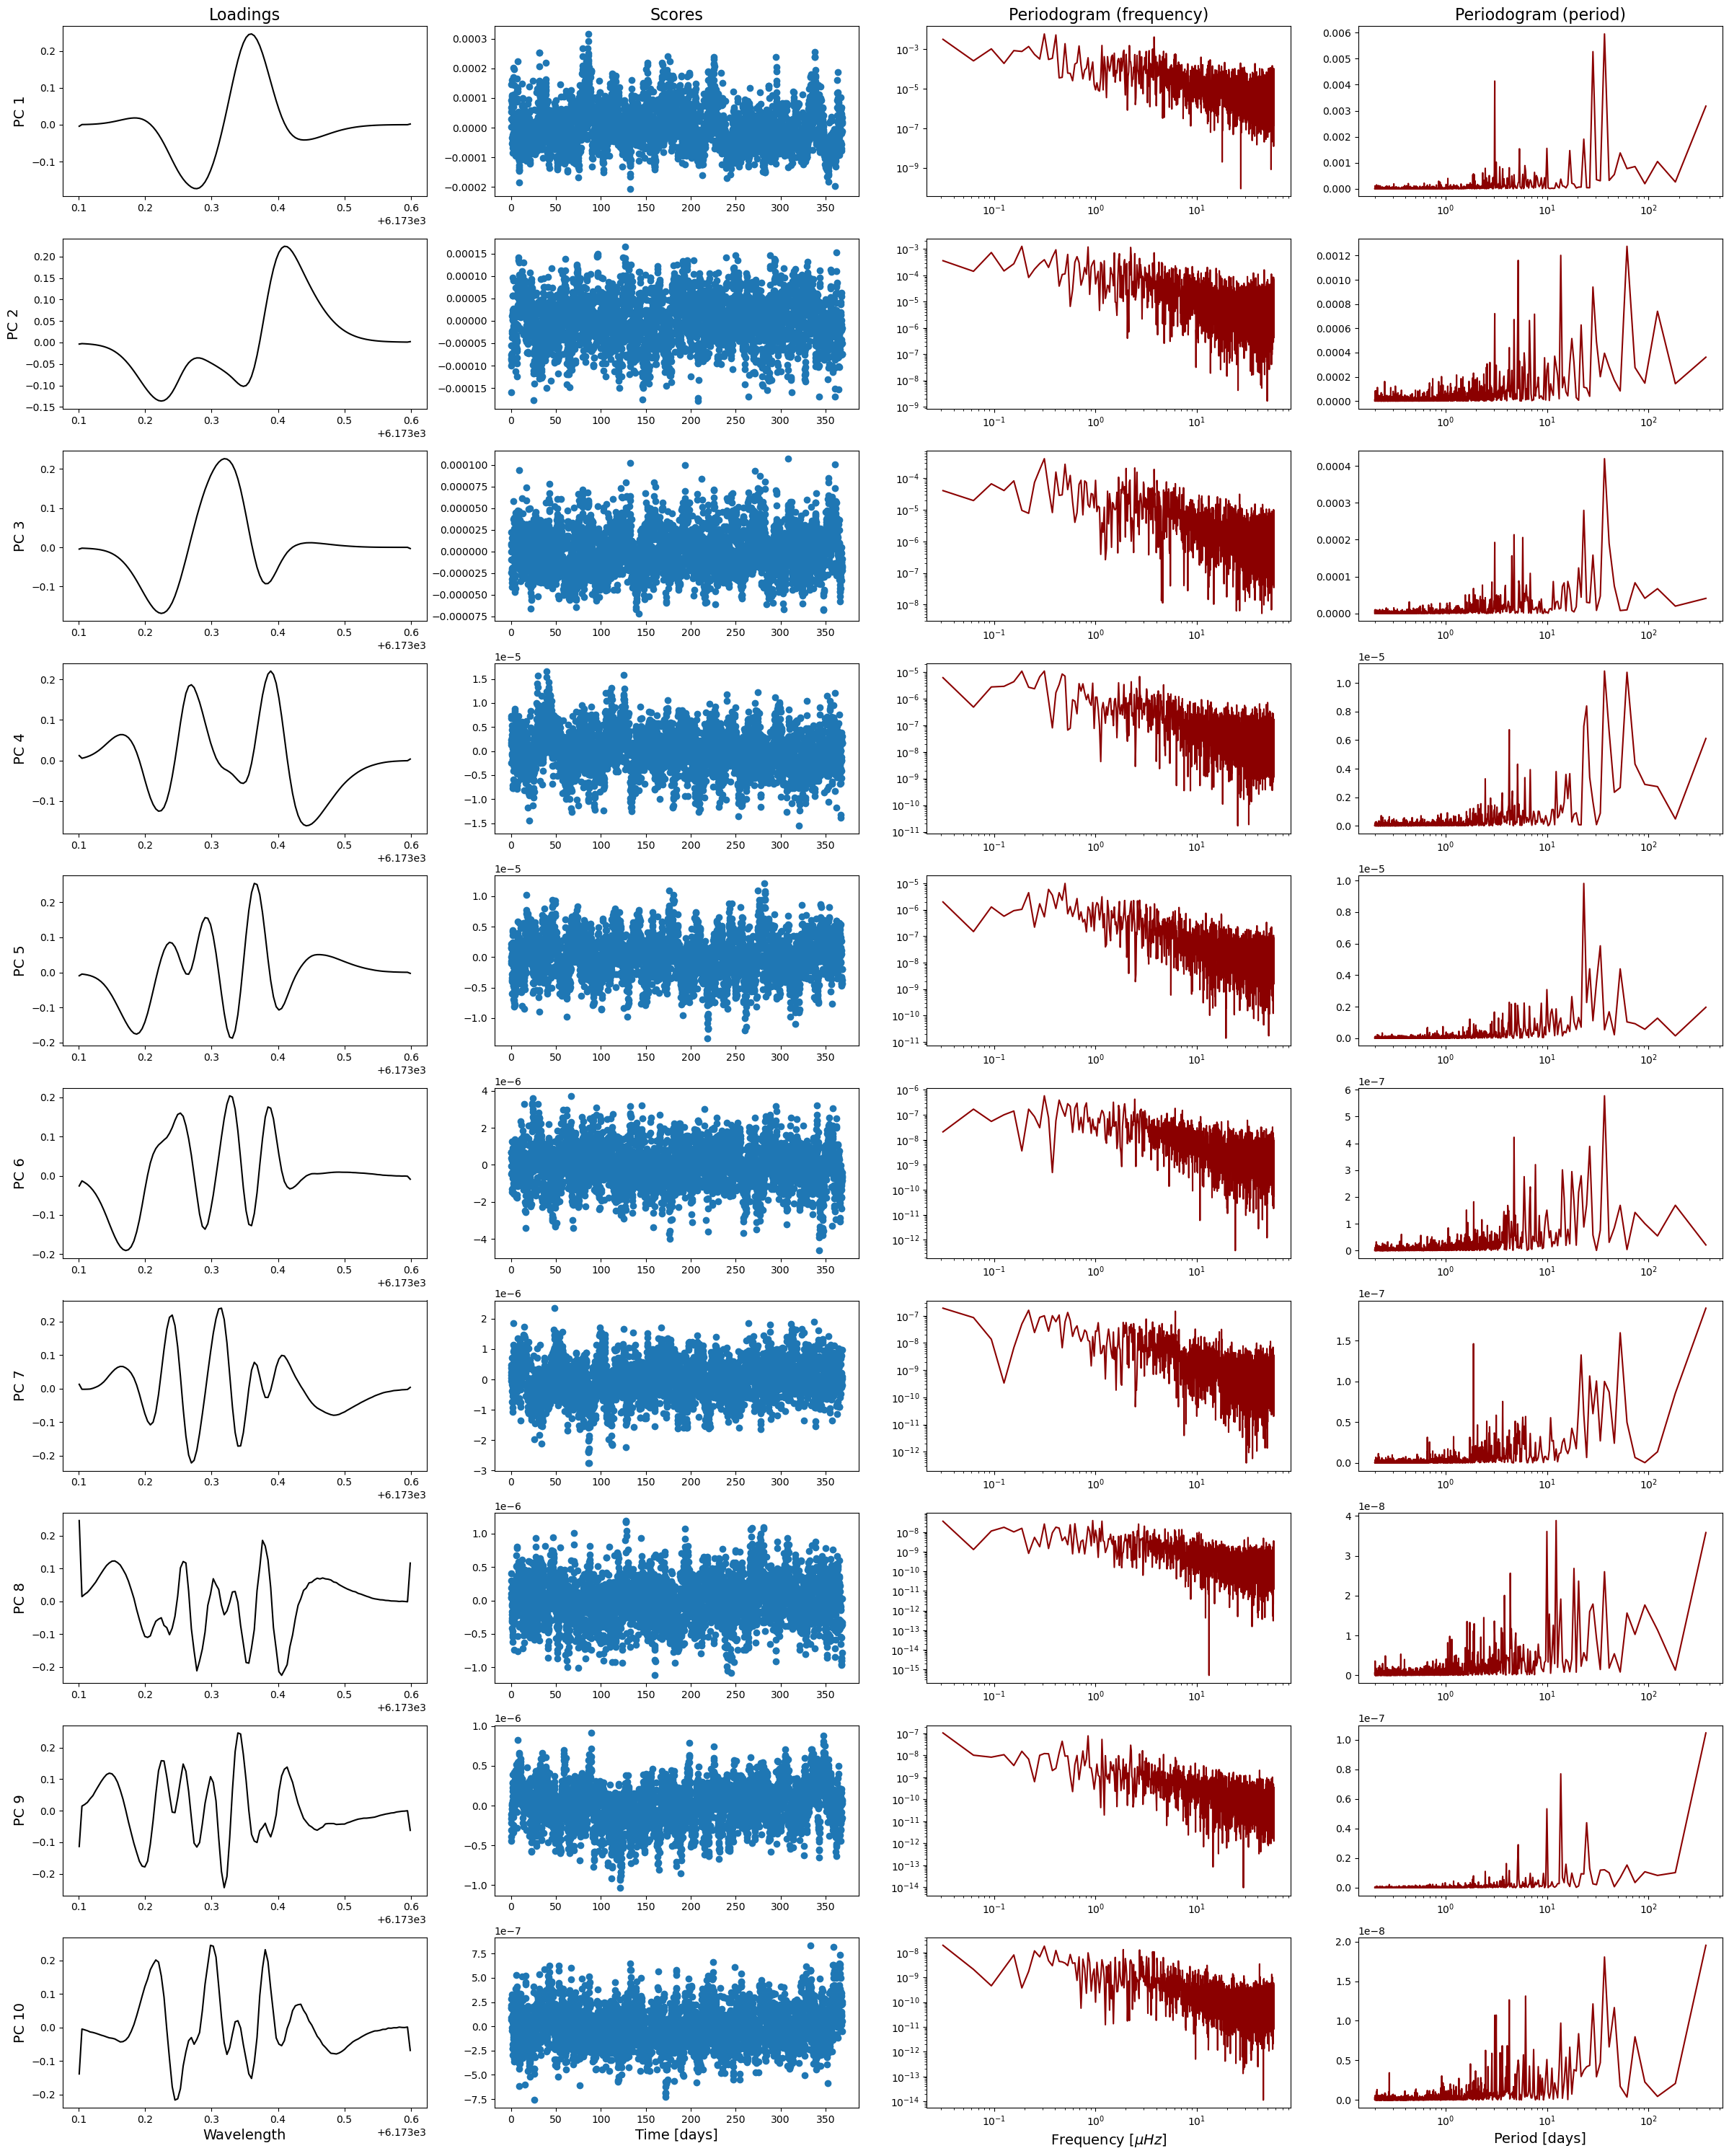

In [87]:
N_pcs = 10

fig, axs = plt.subplots(N_pcs, 4, figsize=(24, 3 * N_pcs))

for i in range(N_pcs):
    if i == min(range(N_pcs)):
        axs[i][0].set_title('Loadings', size=16)
        axs[i][1].set_title('Scores', size=16)
        axs[i][2].set_title('Periodogram (frequency)', size=16)
        axs[i][3].set_title('Periodogram (period)', size=16)
    if i == max(range(N_pcs)):
        axs[i][0].set_xlabel('Wavelength', size=14)
        axs[i][1].set_xlabel('Time [days]', size=14)
        axs[i][2].set_xlabel(r'Frequency [$\mu Hz$]', size=14)
        axs[i][3].set_xlabel('Period [days]', size=14)
        
    # Loadings
    axs[i][0].plot(wl, loadings[i], color='k')
    axs[i][0].set_ylabel(f'PC {i + 1}', size=14)
    
    # Scores
    axs[i][1].scatter(times, scores[i])

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[i][2].plot(freq[i][mask] * 10**6, ps[i][mask], color='darkred')  # frequency in Hz multiplied by 10^6 to pass to microhertz
    axs[i][2].set_yscale('log')
    axs[i][2].set_xscale('log')
    
    # Fourier periodogram (period)
    axs[i][3].plot(1 / (freq[i][mask] * 86400), ps[i][mask], color='darkred')  # frequency in Hz divided by 86400 to pass from to days^-1
    #axs[i][3].set_yscale('log')
    axs[i][3].set_xscale('log')

fig.tight_layout()
plt.show()

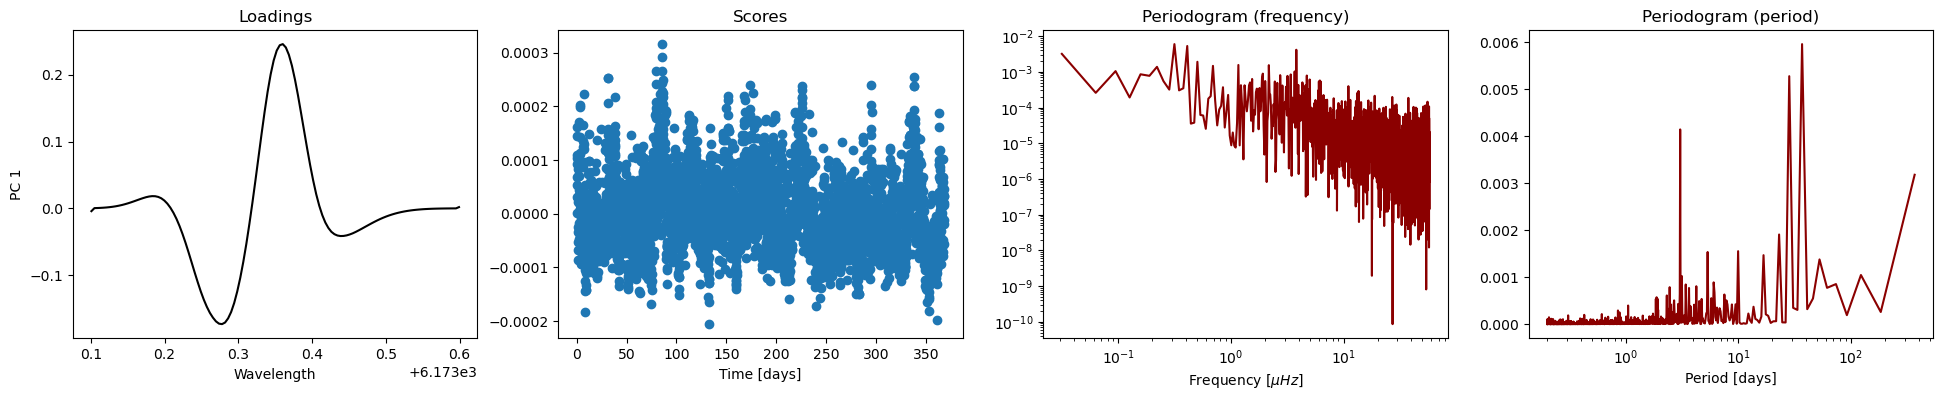

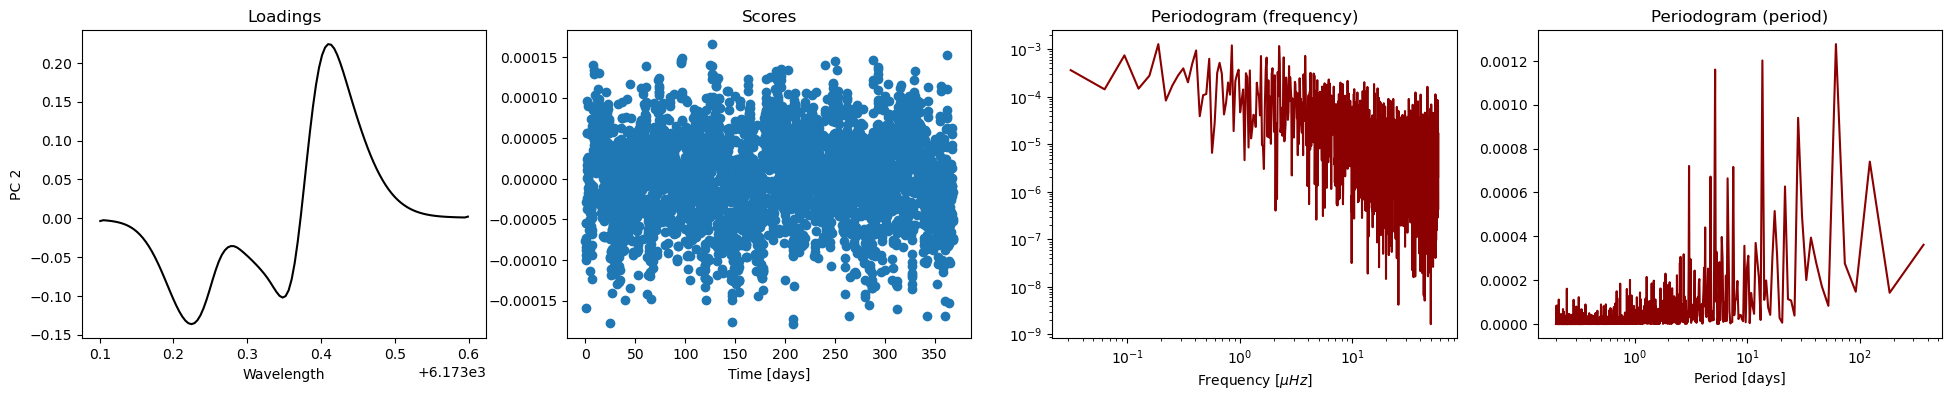

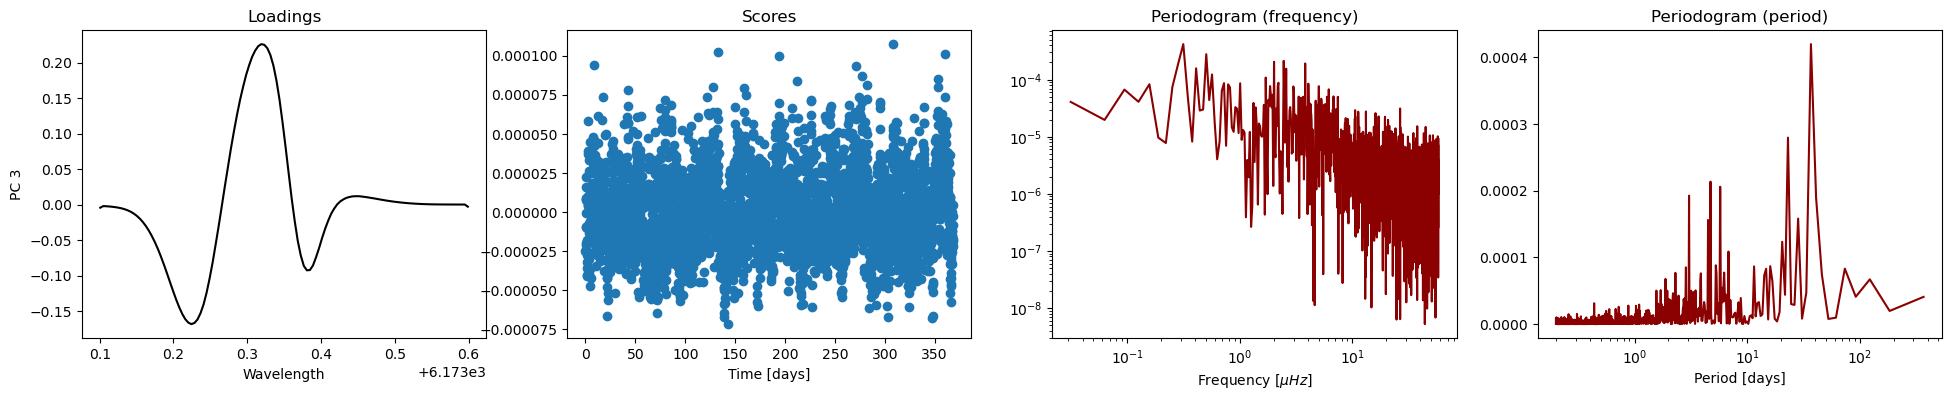

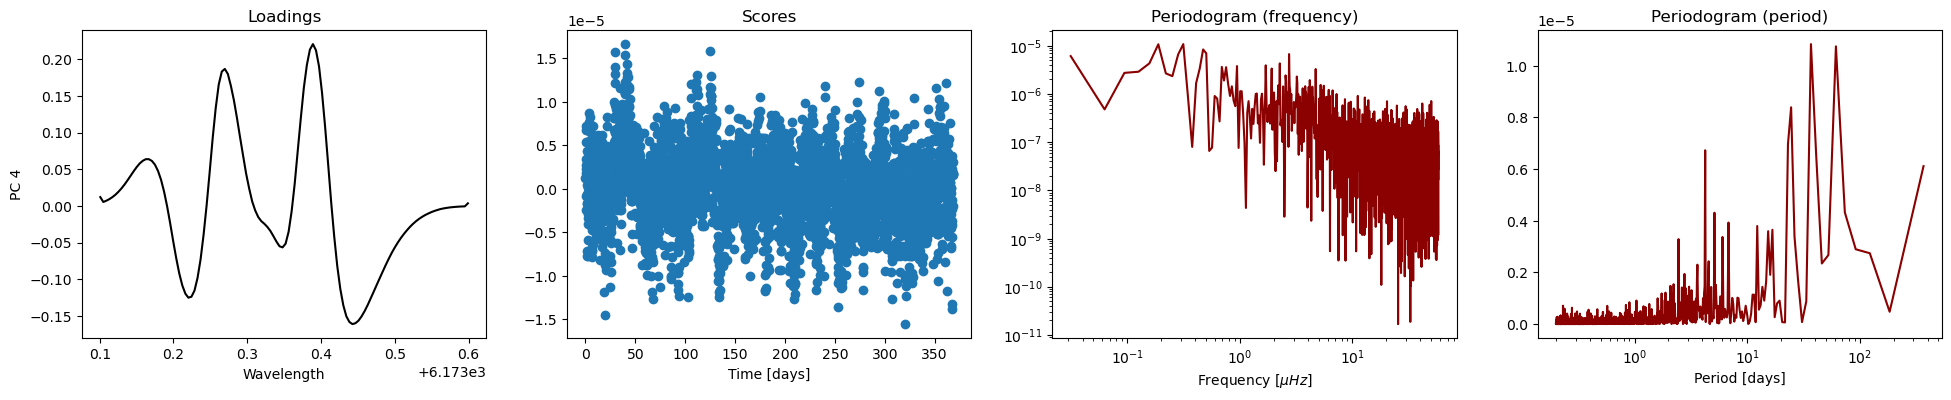

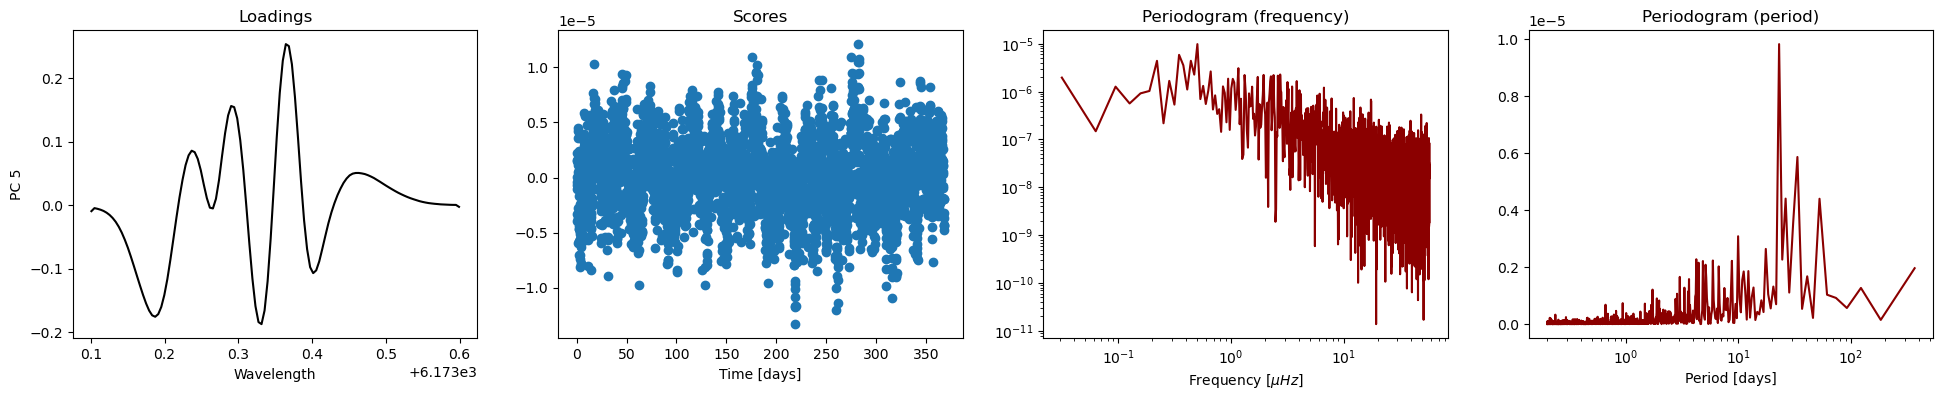

In [79]:
# plot
for i in range(5):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, loadings[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, scores[i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] * 10**6, ps[i][mask], color='darkred')  # frequency in Hz multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram (frequency)', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')
    
    # Fourier periodogram (period)
    axs[3].plot(1 / (freq[i][mask] * 86400), ps[i][mask], color='darkred')  # frequency in Hz divided by 86400 to pass from to days^-1
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram (period)', size=12)
    axs[3].set_xlabel('Period [days]')

    plt.show()